In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import networkx as nx
from optimization_script import run_optimization
import stim
import random

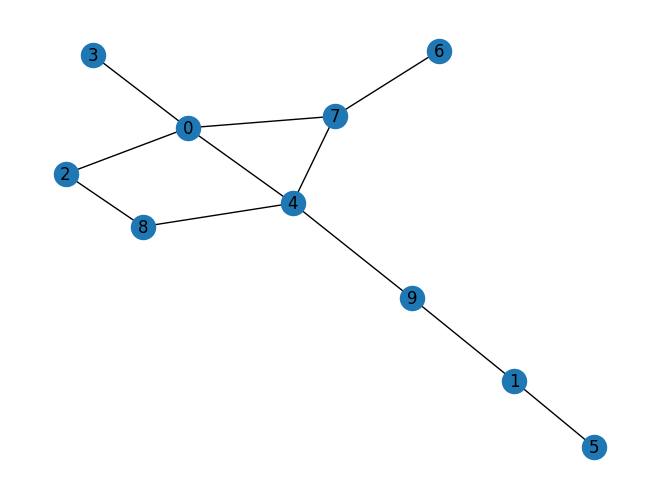

In [ ]:
#use this function to generate connected erdos renyi graphs the default erdos renyi generator may produce disconnected graphs
def connected_erdos_renyi_graph(n, p, seed=None, max_tries=10000):
    """
    Generate a connected Erdős Rényi random graph G(n, p).
    Retries until the generated graph is connected.

    Parameters
    ----------
    n : int
        Number of nodes.
    p : float
        Probability for edge creation.
    seed : int or None, optional
        Random seed for reproducibility.
    max_tries : int, optional
        Maximum number of attempts before giving up.

    Returns
    -------
    G : networkx.Graph
        A connected Erdős–Rényi graph.

    Raises
    ------
    RuntimeError
        If no connected graph is found after max_tries attempts.
    """
    rng = random.Random(seed)
    for _ in range(max_tries):
        # Generate a new random graph using a different seed each time
        current_seed = rng.randrange(1_000_000_000)
        G = nx.erdos_renyi_graph(n, p, seed=current_seed)
        if nx.is_connected(G):
            return G
    raise RuntimeError(f"Failed to generate a connected graph after {max_tries} attempts.")


G = connected_erdos_renyi_graph(10, 0.1, seed=42)
nx.draw(G, with_labels=True)


In [ ]:
node_number_min = 6
node_number_max = 30
node_number_list = list(range(node_number_min,node_number_max+1,1))
print(l)

[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


In [36]:
import os
import pickle
# Parameters: change these as needed
node_number = 6
num_graphs = 10
prob_list = [0.1,0.2,0.3,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.8,0.9]
base_seed = 42

node_number_min = 6
node_number_max = 30
node_number_list = list(range(node_number_min,node_number_max+1,1))

for node_number in node_number_list:
    # Output directory where graphs will be stored (one folder per node count)
    out_dir = f"random_graph_db/graph_db_node_{node_number}"
    os.makedirs(out_dir, exist_ok=True)
    # Container for graphs in-memory (optional)
    graphs_db = {}
    rng = random.Random(base_seed)
    # Helper to save NetworkX graph objects robustly across NetworkX versions
    def save_graph(G, path):
        """Save a graph object to `path`. Tries NetworkX gpickle writer, falls back to pickle.dump."""
        try:
            write = getattr(nx, 'write_gpickle', None)
            if write is not None:
                write(G, path)
                return
            from networkx.readwrite import gpickle
            gpickle.write_gpickle(G, path)
            return
        except Exception:
            with open(path, 'wb') as f:
                pickle.dump(G, f)
    for p_idx, p in enumerate(prob_list, start=1):
        graphs_db[p] = []
        attempts = 0
        max_attempts = num_graphs * 100
        p_safe = str(p)
        # prefix folders/files with zero-padded index: 01_p0.10, 02_p0.20, ...
        p_prefix = f"{p_idx:02d}"
        p_dir = os.path.join(out_dir, f"{p_prefix}_p{p_safe}")
        os.makedirs(p_dir, exist_ok=True)
        while len(graphs_db[p]) < num_graphs and attempts < max_attempts:
            s = rng.randrange(1_000_000_000)
            try:
                G = connected_erdos_renyi_graph(node_number, p, seed=s)
            except RuntimeError:
                attempts += 1
                continue
            # ensure uniqueness up to isomorphism
            if any(nx.is_isomorphic(G, H) for H in graphs_db[p]):
                attempts += 1
                continue
            # store in memory and save to disk as a gpickle (preserves graph object)
            graphs_db[p].append(G)
            idx = len(graphs_db[p])
            # include the p-index prefix in filenames so sorting is consistent
            fname = os.path.join(p_dir, f"{p_prefix}_graph_n{node_number}_p{p_safe}_idx{idx}.gpickle")
            save_graph(G, fname)
            attempts += 1
        print(f"p={p}: generated {len(graphs_db[p])} unique graphs after {attempts} attempts (saved to {p_dir})")
    print("-------------------------------All done. Graphs saved under:-------------------------------", out_dir)

p=0.1: generated 10 unique graphs after 57 attempts (saved to random_graph_db/graph_db_node_6/01_p0.1)
p=0.2: generated 10 unique graphs after 13 attempts (saved to random_graph_db/graph_db_node_6/02_p0.2)
p=0.3: generated 10 unique graphs after 12 attempts (saved to random_graph_db/graph_db_node_6/03_p0.3)
p=0.4: generated 10 unique graphs after 10 attempts (saved to random_graph_db/graph_db_node_6/04_p0.4)
p=0.45: generated 10 unique graphs after 12 attempts (saved to random_graph_db/graph_db_node_6/05_p0.45)
p=0.5: generated 10 unique graphs after 12 attempts (saved to random_graph_db/graph_db_node_6/06_p0.5)
p=0.55: generated 10 unique graphs after 11 attempts (saved to random_graph_db/graph_db_node_6/07_p0.55)
p=0.6: generated 10 unique graphs after 12 attempts (saved to random_graph_db/graph_db_node_6/08_p0.6)
p=0.65: generated 10 unique graphs after 10 attempts (saved to random_graph_db/graph_db_node_6/09_p0.65)
p=0.7: generated 10 unique graphs after 13 attempts (saved to rando

Loaded graph: ./random_graph_db/graph_db_node_6/09_p0.65/09_graph_n6_p0.65_idx1.gpickle -> nodes=6, edges=10
adjacency shape: (6, 6)


/Users/konstantinosrafailrevis/Desktop/PhD/0paul_state_gen/photonic-graphstate-generator-main/lib/generate_graph.py:133: RuntimeWarning: overflow encountered in divide
  if next_cost < current_cost or random.random() < np.exp((current_cost - next_cost)/temperature):


number of emitters: 2
number of emitter CNOTS: 2


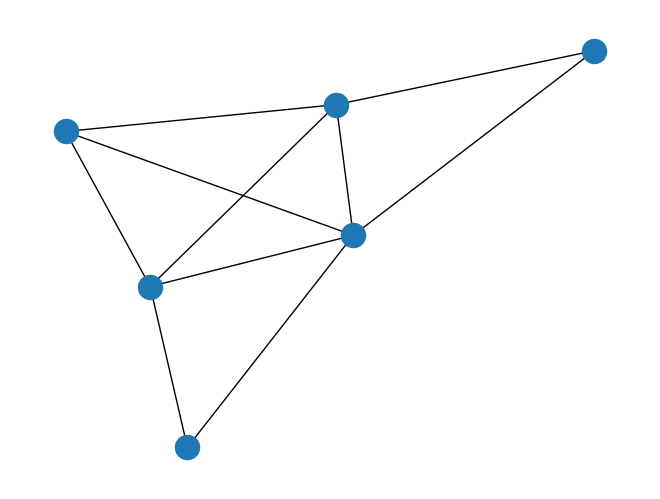

In [22]:
# Load a saved graph as a NetworkX object (no drawing)
import glob
import os
import pickle
import networkx as nx

def find_saved_graph(node_number, p, idx=None, search_root='.'):
    """Return path to a saved graph matching node_number and p (or None)."""
    p_safe = str(p)
    patterns = [
        f"**/*graph_n{node_number}_p{p_safe}_idx*.gpickle",
        f"**/*_graph_n{node_number}_p{p_safe}_idx*.gpickle",
        f"**/*p{p_safe}*/**/*graph_n{node_number}_p{p_safe}_idx*.gpickle",
        f"**/*p{p_safe}*/**/*_graph_n{node_number}_p{p_safe}_idx*.gpickle"
    ]
    matches = []
    for pat in patterns:
        matches.extend(glob.glob(os.path.join(search_root, pat), recursive=True))
    matches = sorted(set(matches))
    if not matches:
        return None
    if idx is not None:
        candidates = [m for m in matches if f"_idx{idx}.gpickle" in m]
        if candidates:
            return candidates[0]
    return matches[0]

def load_graph_from_file(path):
    """Load NetworkX graph from a .gpickle or pickled file."""
    try:
        return nx.read_gpickle(path)
    except Exception:
        with open(path, 'rb') as f:
            return pickle.load(f)

# Example: load without drawing
node_number = 6
p = 0.65
idx = None            # or set integer if you want a particular saved index
search_root = '.'     # change to project root if running from another folder

path = find_saved_graph(node_number, p, idx=idx, search_root=search_root)
if path is None:
    raise FileNotFoundError(f"No saved graph found for n={node_number}, p={p} under {search_root}")

G = load_graph_from_file(path)
print(f"Loaded graph: {path} -> nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")

adj = nx.to_numpy_array(G, dtype=int)
print("adjacency shape:", adj.shape)
nx.draw(G)

opt_graph, circuit, stats = run_optimization(G)


number_of_emitters = stats[0]
print("number of emitters:", number_of_emitters)
number_of_emitter_CNOTs = stats[1]
print("number of emitter CNOTS:", number_of_emitter_CNOTs)


In [ ]:
# Batch-process saved graphs: compute number of emitters and emitter CNOTs for each saved graph (incremental save)
import glob
import os
import re
import csv
import time
from pathlib import Path

# Where to search for saved graphs (relative to notebook location)
search_root = '.'
# patterns that match both old and new naming conventions
patterns = [
    os.path.join(search_root, '**', 'graph_n*_p*_idx*.gpickle'),
    os.path.join(search_root, '**', '_graph_n*_p*_idx*.gpickle'),
    os.path.join(search_root, '**', '*_graph_n*_p*_idx*.gpickle'),
    os.path.join(search_root, '**', '*graph_n*_p*_idx*.gpickle'),
    os.path.join(search_root, '**', '*_idx*.gpickle')
]

# gather candidate files
files = []
for pat in patterns:
    files.extend(sorted(glob.glob(pat, recursive=True)))
# filter to .gpickle only and remove duplicates
files = sorted({f for f in files if f.lower().endswith('.gpickle')})
if not files:
    print('No .gpickle files found under', search_root)
else:
    print(f'Found {len(files)} candidate .gpickle files; processing...')

# output CSV path (incrementally appended)
out_csv = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'graph_stats.csv')
fieldnames = ['path','node_number','p','idx','num_emitters','num_emitter_CNOTs']
# ensure header exists (create file if missing)
if not os.path.exists(out_csv):
    with open(out_csv, 'w', newline='') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()

start = time.time()
for i, path in enumerate(files):
    print(f'[{i+1}/{len(files)}] Processing: {path}')
    try:
        # attempt to extract metadata from filename
        # look for graph_n{n}_p{p}_idx{k} pattern
        m = re.search(r'graph_n(\d+)_p([0-9\.]+)_idx(\d+)', path)
        if m:
            node_n = int(m.group(1))
            p_val = float(m.group(2))
            idx_val = int(m.group(3))
        else:
            # try to fall back to other filename formats
            m2 = re.search(r'_idx(\d+)\.gpickle', path)
            idx_val = int(m2.group(1)) if m2 else None
            m3 = re.search(r'p([0-9\.]+)', path)
            p_val = float(m3.group(1)) if m3 else None
            m4 = re.search(r'graph_n(\d+)', path)
            node_n = int(m4.group(1)) if m4 else None
        # load graph (use helper if available)
        try:
            G = load_graph_from_file(path)
        except NameError:
            import networkx as nx
            G = nx.read_gpickle(path)
        # run optimization (assumes run_optimization imported at top of notebook)
        try:
            opt_graph, circuit, stats = run_optimization(G)
        except Exception as e:
            print('run_optimization failed for', path, '->', e)
            stats = None
        if stats is None:
            num_emitters = None
            num_emitter_CNOTs = None
        else:
            # stats expected to be an iterable with at least two entries
            num_emitters = stats[0] if len(stats) > 0 else None
            num_emitter_CNOTs = stats[1] if len(stats) > 1 else None
        print(f'  -> emitters={num_emitters}, emitter_CNOTs={num_emitter_CNOTs}')
    except Exception as e:
        print('  ERROR processing', path, ':', e)
        node_n = None
        p_val = None
        idx_val = None
        num_emitters = None
        num_emitter_CNOTs = None
    # write row immediately so results are visible during long runs
    row = {
        'path': path,
        'node_number': node_n,
        'p': p_val,
        'idx': idx_val,
        'num_emitters': num_emitters,
        'num_emitter_CNOTs': num_emitter_CNOTs
    }
    # append to CSV (file opened and closed per row to ensure data flushed to disk)
    try:
        with open(out_csv, 'a', newline='') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writerow(row)
    except Exception as e:
        print('  ERROR writing row to CSV:', e)

elapsed = time.time() - start
print(f'Done. Processed {len(files)} files in {elapsed:.1f}s. Results saved (incrementally) to {out_csv}')

Found 3120 candidate .gpickle files; processing...
[1/3120] Processing: ./graph_db_node_6/p_0_1/graph_n6_p0_1_idx1.gpickle


/Users/konstantinosrafailrevis/Desktop/PhD/0paul_state_gen/photonic-graphstate-generator-main/lib/generate_graph.py:133: RuntimeWarning: overflow encountered in divide
  if next_cost < current_cost or random.random() < np.exp((current_cost - next_cost)/temperature):


  -> emitters=1, emitter_CNOTs=0
[2/3120] Processing: ./graph_db_node_6/p_0_1/graph_n6_p0_1_idx10.gpickle
  -> emitters=1, emitter_CNOTs=0
[3/3120] Processing: ./graph_db_node_6/p_0_1/graph_n6_p0_1_idx2.gpickle
  -> emitters=1, emitter_CNOTs=0
[4/3120] Processing: ./graph_db_node_6/p_0_1/graph_n6_p0_1_idx3.gpickle
  -> emitters=1, emitter_CNOTs=0
[5/3120] Processing: ./graph_db_node_6/p_0_1/graph_n6_p0_1_idx4.gpickle
  -> emitters=1, emitter_CNOTs=0
[6/3120] Processing: ./graph_db_node_6/p_0_1/graph_n6_p0_1_idx5.gpickle
  -> emitters=1, emitter_CNOTs=0
[7/3120] Processing: ./graph_db_node_6/p_0_1/graph_n6_p0_1_idx6.gpickle
  -> emitters=1, emitter_CNOTs=0
[8/3120] Processing: ./graph_db_node_6/p_0_1/graph_n6_p0_1_idx7.gpickle
  -> emitters=1, emitter_CNOTs=0
[9/3120] Processing: ./graph_db_node_6/p_0_1/graph_n6_p0_1_idx8.gpickle
  -> emitters=1, emitter_CNOTs=0
[10/3120] Processing: ./graph_db_node_6/p_0_1/graph_n6_p0_1_idx9.gpickle
  -> emitters=2, emitter_CNOTs=2
[11/3120] Processing

Saved heatmap to /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/emitters_heatmap.png


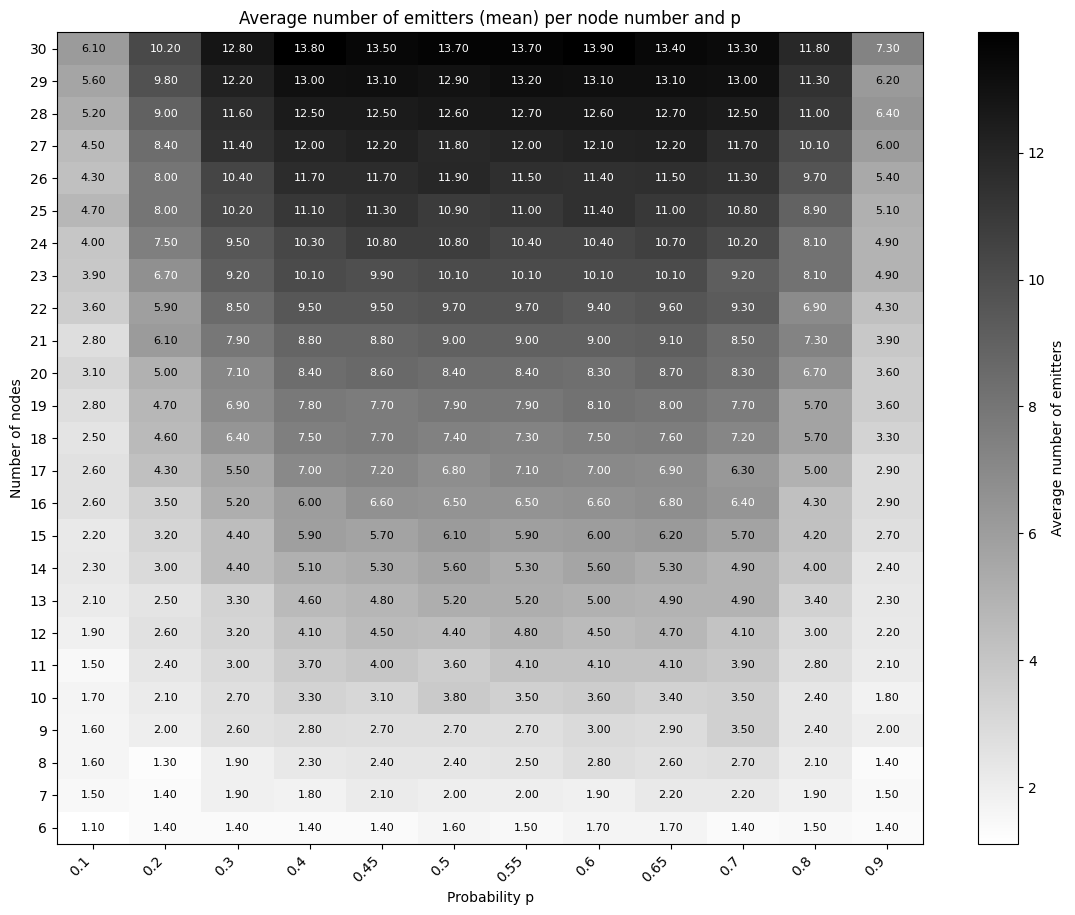

In [22]:
# Plot heatmap: average number of emitters per (node_number, probability)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

csv_path = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'graph_stats.csv')
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Expected results CSV not found: {csv_path}")

# read results and compute mean emitters per (node_number, p)
df = pd.read_csv(csv_path)
# keep only valid numeric emitter entries
df = df[df['num_emitters'].notna()]
df['node_number'] = pd.to_numeric(df['node_number'], errors='coerce')
df['p'] = pd.to_numeric(df['p'], errors='coerce')
df = df[df['node_number'].notna() & df['p'].notna()]

# list of probabilities in the desired order
prob_list = [0.1,0.2,0.3,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.8,0.9]

# group and compute mean
group = df.groupby(['node_number','p'])['num_emitters'].mean().reset_index()
# pivot to matrix: rows=node_number, cols=p
pivot = group.pivot(index='node_number', columns='p', values='num_emitters')
# reindex columns to desired prob order (columns might be floats)
pivot = pivot.reindex(columns=prob_list)
# sort rows by node_number ascending
pivot = pivot.sort_index()

# prepare data for plotting
nodes = pivot.index.astype(int).tolist()
probs = pivot.columns.tolist()
data = pivot.values.astype(float)  # contains NaN for missing cells

fig, ax = plt.subplots(figsize=(len(probs)*0.8 + 2, len(nodes)*0.25 + 3))
cmap = plt.get_cmap('binary')
im = ax.imshow(data, aspect='auto', origin='lower', cmap=cmap)
# ticks
ax.set_xticks(np.arange(len(probs)))
ax.set_xticklabels([str(p) for p in probs], rotation=45, ha='right')
ax.set_yticks(np.arange(len(nodes)))
ax.set_yticklabels(nodes)
ax.set_xlabel('Probability p')
ax.set_ylabel('Number of nodes')
ax.set_title('Average number of emitters (mean) per node number and p')
# annotate each cell with its value (rounded)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if np.isnan(val):
            txt = ''
        else:
            txt = f"{val:.2f}"
        ax.text(j, i, txt, ha='center', va='center', color='white' if (not np.isnan(val) and val > np.nanmean(data)) else 'black', fontsize=8)
# colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Average number of emitters')

# save figure
out_fig = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'emitters_heatmap.png')
fig.tight_layout()
fig.savefig(out_fig, dpi=700)
print(f'Saved heatmap to {out_fig}')
plt.show()

Saved heatmap to /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/emitter_CNOTs_heatmap.png


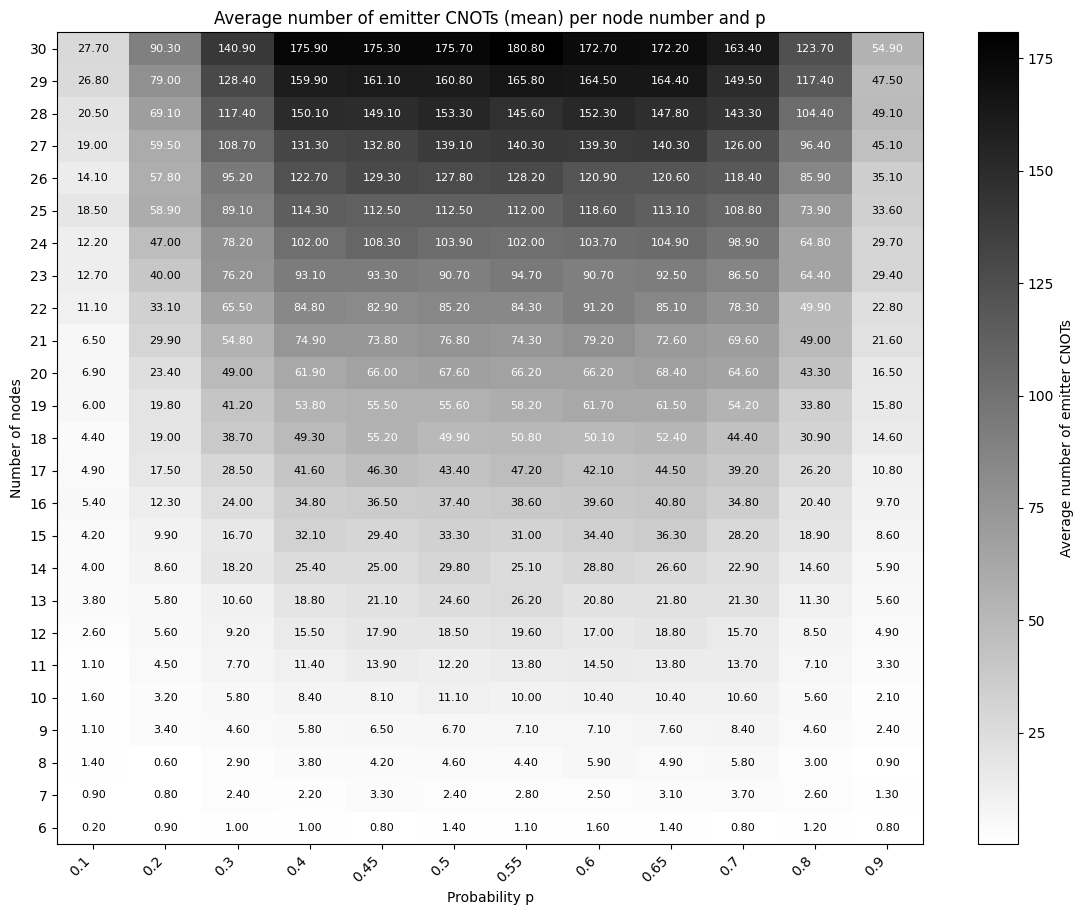

In [23]:
# Plot heatmap: average number of emitter CNOTs per (node_number, probability)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

csv_path = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'graph_stats.csv')
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Expected results CSV not found: {csv_path}")

# read results and compute mean emitter CNOTs per (node_number, p)
df = pd.read_csv(csv_path)
# keep only valid numeric emitter-CNOT entries
df = df[df['num_emitter_CNOTs'].notna()]
df['node_number'] = pd.to_numeric(df['node_number'], errors='coerce')
df['p'] = pd.to_numeric(df['p'], errors='coerce')
df = df[df['node_number'].notna() & df['p'].notna()]

# list of probabilities in the desired order
prob_list = [0.1,0.2,0.3,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.8,0.9]

# group and compute mean
group = df.groupby(['node_number','p'])['num_emitter_CNOTs'].mean().reset_index()
# pivot to matrix: rows=node_number, cols=p
pivot = group.pivot(index='node_number', columns='p', values='num_emitter_CNOTs')
# reindex columns to desired prob order (columns might be floats)
pivot = pivot.reindex(columns=prob_list)
# sort rows by node_number ascending
pivot = pivot.sort_index()

# prepare data for plotting
nodes = pivot.index.astype(int).tolist()
probs = pivot.columns.tolist()
data = pivot.values.astype(float)  # contains NaN for missing cells

fig, ax = plt.subplots(figsize=(len(probs)*0.8 + 2, len(nodes)*0.25 + 3))
cmap = plt.get_cmap('binary')
im = ax.imshow(data, aspect='auto', origin='lower', cmap=cmap)
# ticks
ax.set_xticks(np.arange(len(probs)))
ax.set_xticklabels([str(p) for p in probs], rotation=45, ha='right')
ax.set_yticks(np.arange(len(nodes)))
ax.set_yticklabels(nodes)
ax.set_xlabel('Probability p')
ax.set_ylabel('Number of nodes')
ax.set_title('Average number of emitter CNOTs (mean) per node number and p')
# annotate each cell with its value (rounded)
mean_all = np.nanmean(data)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if np.isnan(val):
            txt = ''
        else:
            txt = f"{val:.2f}"
        color = 'white' if (not np.isnan(val) and val > mean_all) else 'black'
        ax.text(j, i, txt, ha='center', va='center', color=color, fontsize=8)
# colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Average number of emitter CNOTs')

# save figure
out_fig = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'emitter_CNOTs_heatmap.png')
fig.tight_layout()
fig.savefig(out_fig, dpi=700)
print(f'Saved heatmap to {out_fig}')
plt.show()

#### Evas algos plotted

Saved /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/emitters_heatmap_naive_vs_heu.png


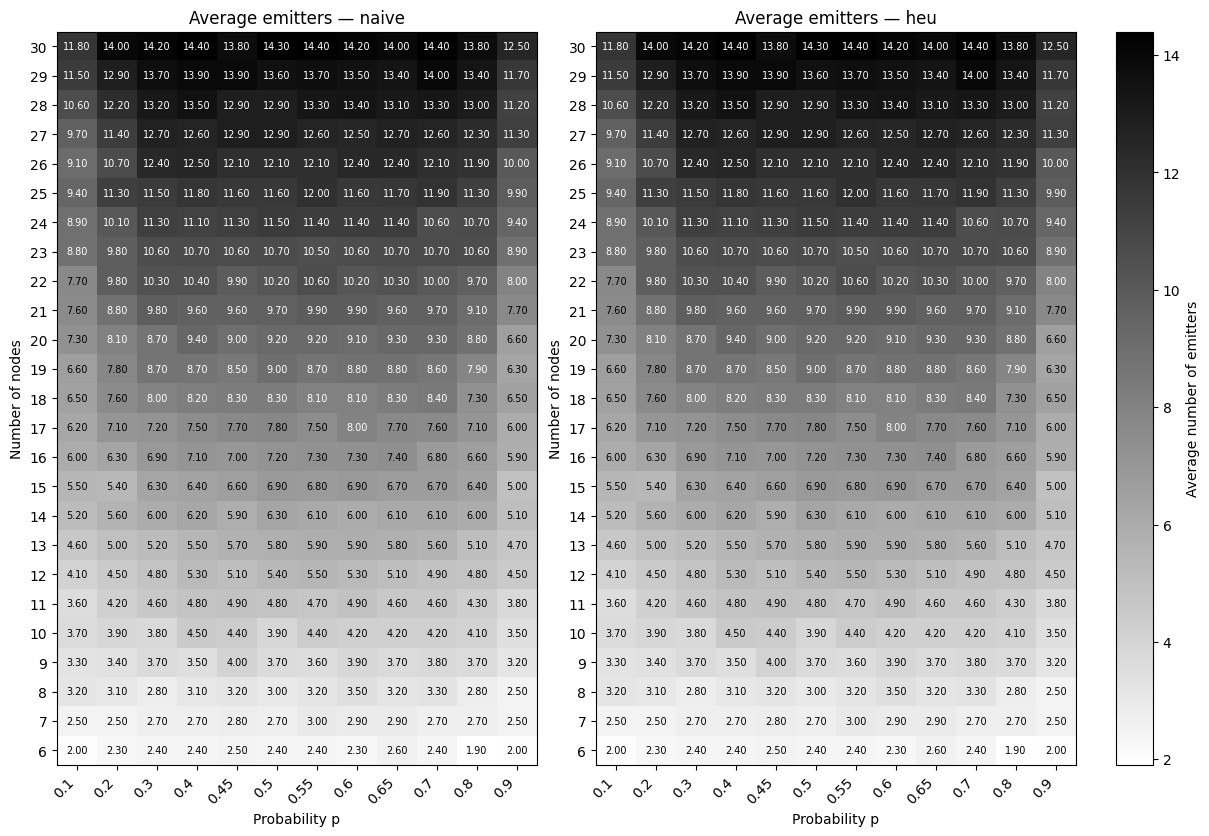

Done plotting emitters from /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/graph_stats_eva.csv
Saved /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/cnots_heatmap_naive_vs_heu.png
Saved /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/cnots_heatmap_naive_vs_heu.png


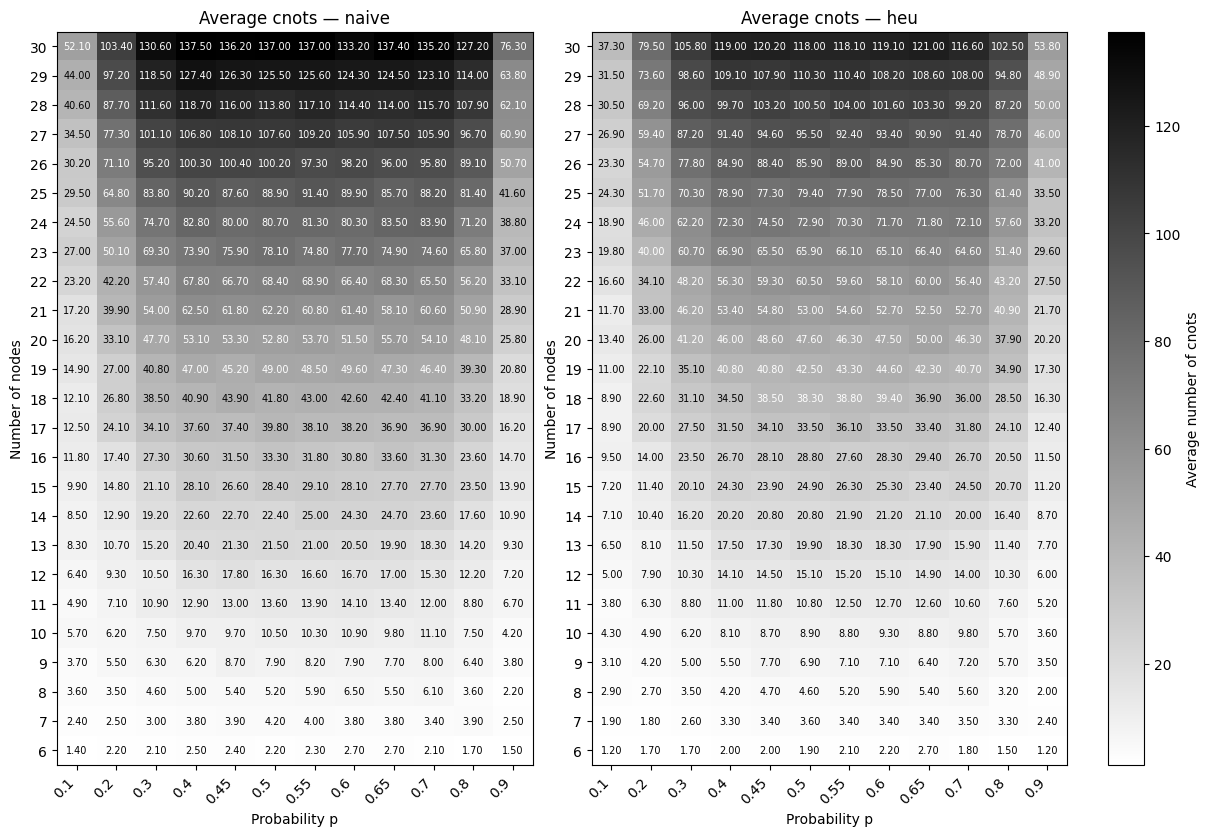

In [24]:
# Plot emitters from graph_stats_eva.csv for the two algorithms: naive and heu
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'graph_stats_eva.csv')
if not os.path.exists(csv_path):
    raise FileNotFoundError(f'Expected file not found: {csv_path}')

# Read CSV (expected columns: path,node_number,p,idx,num_emitters_naive,num_emitters_heu,cnots_naive,cnots_heu)
df = pd.read_csv(csv_path)

# Convert numeric columns
df['node_number'] = pd.to_numeric(df['node_number'], errors='coerce')
df['p'] = pd.to_numeric(df['p'], errors='coerce')

# Algorithms and corresponding columns in this CSV
algorithms = [('naive', 'num_emitters_naive'), ('heu', 'num_emitters_heu')]
# desired probability order (same as elsewhere)
prob_list = [0.1,0.2,0.3,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.8,0.9]

# Prepare pivots and compute global vmin/vmax for a shared color scale
pivots = {}
vmin = np.inf
vmax = -np.inf
rows_present = set()
for alg_label, col in algorithms:
    if col not in df.columns:
        print(f'Column {col} not found — skipping {alg_label}')
        continue
    sub = df[df[col].notna() & df['node_number'].notna() & df['p'].notna()].copy()
    if sub.empty:
        print(f'No valid rows for {alg_label} — skipping')
        continue
    group = sub.groupby(['node_number','p'])[col].mean().reset_index()
    pivot = group.pivot(index='node_number', columns='p', values=col)
    pivot = pivot.reindex(columns=prob_list)
    pivot = pivot.sort_index()
    pivots[alg_label] = pivot
    data = pivot.values.astype(float)
    # track vmin/vmax ignoring NaN
    if np.isfinite(data).any():
        vmin = min(vmin, np.nanmin(data))
        vmax = max(vmax, np.nanmax(data))
    rows_present.update(pivot.index.tolist())

if not pivots:
    raise RuntimeError('No algorithm columns found or no valid numeric data to plot.')

# sort rows (node numbers) for plotting
nodes_sorted = sorted(rows_present)

# Create side-by-side figure for the two algorithms that exist
n_plots = len(pivots)
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, max(4, len(nodes_sorted)*0.25 + 2)), constrained_layout=True)
if n_plots == 1:
    axes = [axes]

for ax, (alg_label) in zip(axes, list(pivots.keys())):
    pivot = pivots[alg_label]
    # reindex rows to common set so heatmaps align vertically
    pivot = pivot.reindex(index=nodes_sorted)
    probs = pivot.columns.tolist()
    data = pivot.values.astype(float)
    cmap = plt.get_cmap('binary')
    im = ax.imshow(data, aspect='auto', origin='lower', cmap=cmap, vmin=(None if not np.isfinite(vmin) else vmin), vmax=(None if not np.isfinite(vmax) else vmax))
    ax.set_xticks(np.arange(len(probs)))
    ax.set_xticklabels([str(p) for p in probs], rotation=45, ha='right')
    ax.set_yticks(np.arange(len(nodes_sorted)))
    ax.set_yticklabels(nodes_sorted)
    ax.set_xlabel('Probability p')
    ax.set_ylabel('Number of nodes')
    ax.set_title(f'Average emitters — {alg_label}')
    # annotate cells
    mean_all = np.nanmean(data) if np.isfinite(vmin) else np.nan
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            val = data[r, c]
            if np.isnan(val):
                txt = ''
            else:
                txt = f'{val:.2f}'
            color = 'white' if (np.isfinite(mean_all) and not np.isnan(val) and val > mean_all) else 'black'
            ax.text(c, r, txt, ha='center', va='center', color=color, fontsize=7)

# shared colorbar on the right
cbar = fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04)
cbar.set_label('Average number of emitters')

out_fig = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'emitters_heatmap_naive_vs_heu.png') if len(pivots) > 1 else os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', f'emitters_heatmap_{list(pivots.keys())[0]}.png')
fig.savefig(out_fig, dpi=300)
print('Saved', out_fig)
plt.show()
print('Done plotting emitters from', csv_path)

# =======================================================================
# Now do the same for cnots: cnots_naive vs cnots_heu
# =======================================================================
# Columns expected: cnots_naive, cnots_heu
algorithms_cnots = [('naive', 'cnots_naive'), ('heu', 'cnots_heu')]
pivots_cnots = {}
vmin_c = np.inf
vmax_c = -np.inf
rows_present_c = set()
for alg_label, col in algorithms_cnots:
    if col not in df.columns:
        print(f'Column {col} not found — skipping {alg_label}')
        continue
    sub = df[df[col].notna() & df['node_number'].notna() & df['p'].notna()].copy()
    if sub.empty:
        print(f'No valid rows for {alg_label} (cnots) — skipping')
        continue
    group = sub.groupby(['node_number','p'])[col].mean().reset_index()
    pivot = group.pivot(index='node_number', columns='p', values=col)
    pivot = pivot.reindex(columns=prob_list)
    pivot = pivot.sort_index()
    pivots_cnots[alg_label] = pivot
    data_c = pivot.values.astype(float)
    if np.isfinite(data_c).any():
        vmin_c = min(vmin_c, np.nanmin(data_c))
        vmax_c = max(vmax_c, np.nanmax(data_c))
    rows_present_c.update(pivot.index.tolist())

if not pivots_cnots:
    print('No cnots columns found or no valid numeric cnots data to plot.')
else:
    # sort rows for cnots
    nodes_sorted_c = sorted(rows_present_c)
    n_plots_c = len(pivots_cnots)
    fig_c, axes_c = plt.subplots(1, n_plots_c, figsize=(6 * n_plots_c, max(4, len(nodes_sorted_c)*0.25 + 2)), constrained_layout=True)
    if n_plots_c == 1:
        axes_c = [axes_c]
    cmap = plt.get_cmap('binary')
    im_c = None
    for ax_c, alg_label in zip(axes_c, list(pivots_cnots.keys())):
        pivot = pivots_cnots[alg_label]
        pivot = pivot.reindex(index=nodes_sorted_c)
        probs_c = pivot.columns.tolist()
        data_c = pivot.values.astype(float)
        im_c = ax_c.imshow(data_c, aspect='auto', origin='lower', cmap=cmap, vmin=(None if not np.isfinite(vmin_c) else vmin_c), vmax=(None if not np.isfinite(vmax_c) else vmax_c))
        ax_c.set_xticks(np.arange(len(probs_c)))
        ax_c.set_xticklabels([str(p) for p in probs_c], rotation=45, ha='right')
        ax_c.set_yticks(np.arange(len(nodes_sorted_c)))
        ax_c.set_yticklabels(nodes_sorted_c)
        ax_c.set_xlabel('Probability p')
        ax_c.set_ylabel('Number of nodes')
        ax_c.set_title(f'Average cnots — {alg_label}')
        # annotate
        mean_all_c = np.nanmean(data_c) if np.isfinite(vmin_c) else np.nan
        for r in range(data_c.shape[0]):
            for c in range(data_c.shape[1]):
                val = data_c[r, c]
                if np.isnan(val):
                    txt = ''
                else:
                    txt = f'{val:.2f}'
                color = 'white' if (np.isfinite(mean_all_c) and not np.isnan(val) and val > mean_all_c) else 'black'
                ax_c.text(c, r, txt, ha='center', va='center', color=color, fontsize=7)
    # shared colorbar for cnots
    cbar_c = fig_c.colorbar(im_c, ax=axes_c, fraction=0.046, pad=0.04)
    cbar_c.set_label('Average number of cnots')
    out_fig_c = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'cnots_heatmap_naive_vs_heu.png') if len(pivots_cnots) > 1 else os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', f'cnots_heatmap_{list(pivots_cnots.keys())[0]}.png')
    fig_c.savefig(out_fig_c, dpi=300)
    print('Saved', out_fig_c)
    plt.show()

Using columns: num_emitters naive-> num_emitters_naive heu-> num_emitters_heu
Saved /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/emitters_difference_stats_minus_states_naive_vs_heu.png
Saved /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/emitters_difference_stats_minus_states_naive_vs_heu.png


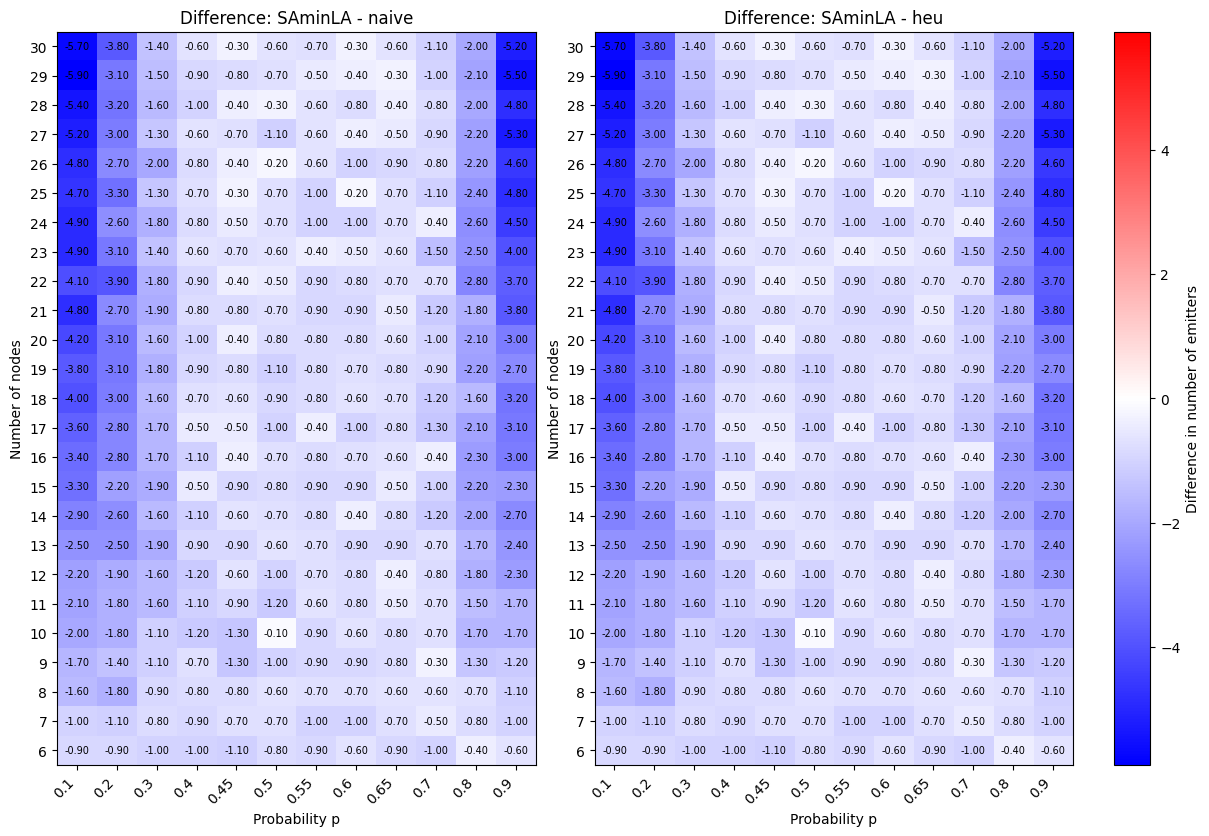

CNOTs columns detected — stats-> num_emitter_CNOTs naive-> cnots_naive heu-> cnots_heu
Saved /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/cnots_difference_stats_minus_states_naive_vs_heu.png
Saved /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/cnots_difference_stats_minus_states_naive_vs_heu.png


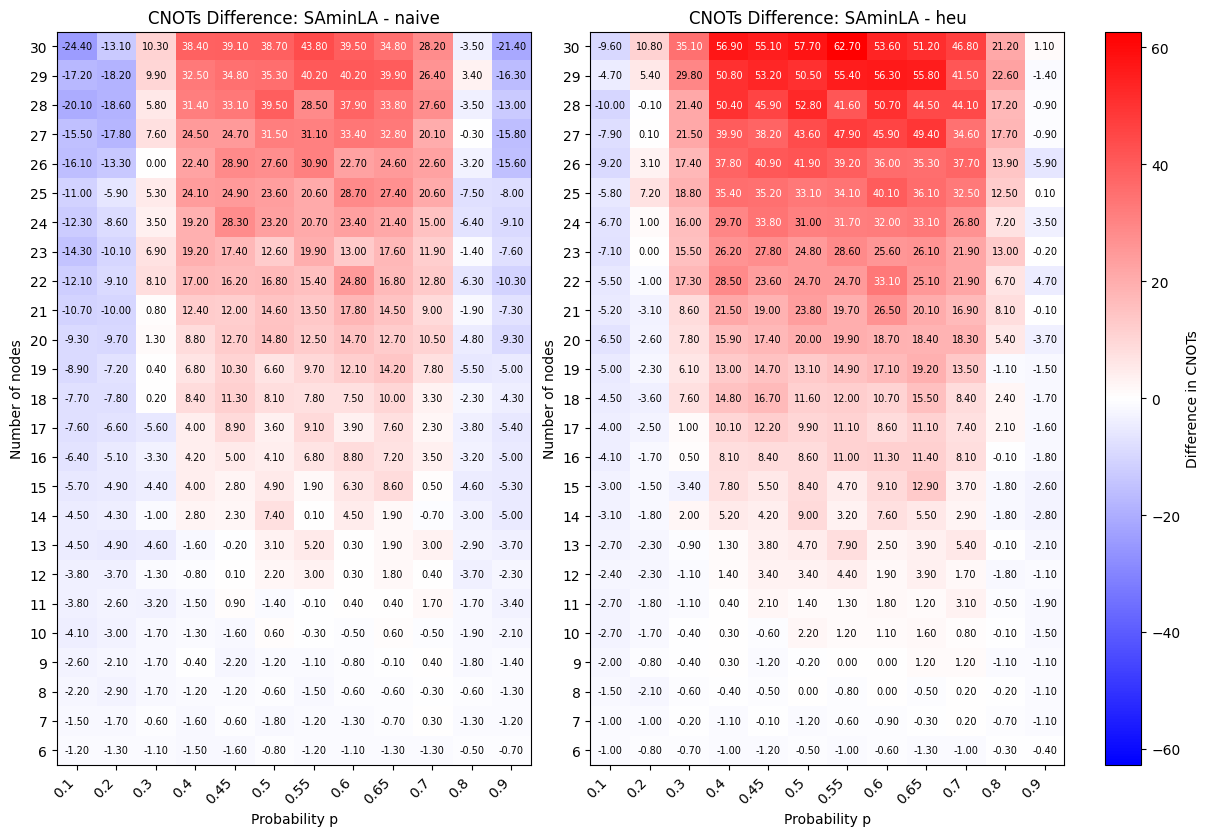

In [25]:
# Plot differences: (graph_stats - graph_stats_eva naive) and (graph_stats - graph_stats_eva heu) side-by-side
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_stats = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'graph_stats.csv')
csv_states = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'graph_stats_eva.csv')
if not os.path.exists(csv_stats):
    raise FileNotFoundError(f'Expected file not found: {csv_stats}')
if not os.path.exists(csv_states):
    raise FileNotFoundError(f'Expected file not found: {csv_states}')

# read files
df_stats = pd.read_csv(csv_stats)
df_states = pd.read_csv(csv_states)

# normalize numeric columns
df_stats['node_number'] = pd.to_numeric(df_stats['node_number'], errors='coerce')
df_stats['p'] = pd.to_numeric(df_stats['p'], errors='coerce')
df_states['node_number'] = pd.to_numeric(df_states['node_number'], errors='coerce')
df_states['p'] = pd.to_numeric(df_states['p'], errors='coerce')

# candidate column names
stats_col_candidates = ['num_emitters', 'num_emitter']
naive_col_candidates = ['num_emitter_naive','num_emitters_naive']
heu_col_candidates = ['num_emitters_heu','num_emitter_heu','num_heu']
stats_col = next((c for c in stats_col_candidates if c in df_stats.columns), None)
naive_col = next((c for c in naive_col_candidates if c in df_states.columns), None)
heu_col = next((c for c in heu_col_candidates if c in df_states.columns), None)
if stats_col is None:
    raise KeyError(f'Could not find any of {stats_col_candidates} in {csv_stats}')
if naive_col is None and heu_col is None:
    raise KeyError(f'Could not find any naive or heu emitter columns in {csv_states}')
print('Using columns:', stats_col, 'naive->', naive_col, 'heu->', heu_col)

# desired probability order
prob_list = [0.1,0.2,0.3,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.8,0.9]

# build pivot for stats
g_stats = df_stats[df_stats[stats_col].notna() & df_stats['node_number'].notna() & df_stats['p'].notna()].copy()
group_stats = g_stats.groupby(['node_number','p'])[stats_col].mean().reset_index()
pivot_stats = group_stats.pivot(index='node_number', columns='p', values=stats_col)
pivot_stats = pivot_stats.reindex(columns=prob_list)

# build pivots for naive and heu if available
pivot_naive = None
pivot_heu = None
if naive_col is not None:
    g_naive = df_states[df_states[naive_col].notna() & df_states['node_number'].notna() & df_states['p'].notna()].copy()
    group_naive = g_naive.groupby(['node_number','p'])[naive_col].mean().reset_index()
    pivot_naive = group_naive.pivot(index='node_number', columns='p', values=naive_col)
    pivot_naive = pivot_naive.reindex(columns=prob_list)
if heu_col is not None:
    g_heu = df_states[df_states[heu_col].notna() & df_states['node_number'].notna() & df_states['p'].notna()].copy()
    group_heu = g_heu.groupby(['node_number','p'])[heu_col].mean().reset_index()
    pivot_heu = group_heu.pivot(index='node_number', columns='p', values=heu_col)
    pivot_heu = pivot_heu.reindex(columns=prob_list)

# union rows across available pivots
rows = set()
if pivot_stats is not None:
    rows.update(pivot_stats.index.tolist())
if pivot_naive is not None:
    rows.update(pivot_naive.index.tolist())
if pivot_heu is not None:
    rows.update(pivot_heu.index.tolist())
all_nodes = sorted(rows)
pivot_stats = pivot_stats.reindex(index=all_nodes)
if pivot_naive is not None:
    pivot_naive = pivot_naive.reindex(index=all_nodes)
if pivot_heu is not None:
    pivot_heu = pivot_heu.reindex(index=all_nodes)

# compute differences where possible
diffs = {}
if pivot_naive is not None:
    diffs['naive'] = (pivot_stats.astype(float) - pivot_naive.astype(float)).values.astype(float)
if pivot_heu is not None:
    diffs['heu'] = (pivot_stats.astype(float) - pivot_heu.astype(float)).values.astype(float)

if not diffs:
    raise RuntimeError('No differences to plot (no matching columns found)')

# determine symmetric color limit across all diffs
all_vals = np.hstack([v[np.isfinite(v)] for v in diffs.values()]) if any(np.isfinite(v).any() for v in diffs.values()) else np.array([])
if all_vals.size:
    lim = max(abs(np.nanmin(all_vals)), abs(np.nanmax(all_vals)))
    vmin, vmax = -lim, lim
else:
    vmin, vmax = None, None

# Plot side-by-side panels for available diffs (no numeric annotations)
n = len(diffs)
fig, axes = plt.subplots(1, n, figsize=(6 * n, max(4, len(all_nodes)*0.25 + 2)), constrained_layout=True)
if n == 1:
    axes = [axes]
cmap = plt.get_cmap('bwr')
for ax, label in zip(axes, diffs.keys()):
    data = diffs[label]
    im = ax.imshow(data, aspect='auto', origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    probs = prob_list
    ax.set_xticks(np.arange(len(probs)))
    ax.set_xticklabels([str(p) for p in probs], rotation=45, ha='right')
    ax.set_yticks(np.arange(len(all_nodes)))
    ax.set_yticklabels(all_nodes)
    ax.set_xlabel('Probability p')
    ax.set_ylabel('Number of nodes')
    ax.set_title(f'Difference: SAminLA - {label}')
    # annotate cells with numeric values
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            val = data[r, c]
            if np.isnan(val):
                txt = ''
            else:
                txt = f'{val:.2f}'
            color = 'white' if (vmin is not None and val > 0 and abs(val) > (lim/2 if lim>0 else 0)) else 'black'
            ax.text(c, r, txt, ha='center', va='center', color=color, fontsize=7)
# shared colorbar
fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04).set_label('Difference in number of emitters')
out_fig = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'emitters_difference_stats_minus_states_naive_vs_heu.png')
fig.savefig(out_fig, dpi=300)
print('Saved', out_fig)
plt.show()

# ------------------------------------------------------------------
# Now repeat the same difference computation/plotting for cnots
# ------------------------------------------------------------------
# candidate column names for cnots in the stats CSV
stats_cnots_candidates = ['num_emitter_CNOTs', 'num_cnots', 'cnots']
cnots_stats_col = next((c for c in stats_cnots_candidates if c in df_stats.columns), None)
# cnots columns in the eva CSV
cnots_naive_candidates = ['cnots_naive']
cnots_heu_candidates = ['cnots_heu']
cnots_naive_col = next((c for c in cnots_naive_candidates if c in df_states.columns), None)
cnots_heu_col = next((c for c in cnots_heu_candidates if c in df_states.columns), None)
if cnots_stats_col is None and (cnots_naive_col is None and cnots_heu_col is None):
    print('No cnot columns found in either CSV — skipping cnot comparison')
else:
    print('CNOTs columns detected — stats->', cnots_stats_col, 'naive->', cnots_naive_col, 'heu->', cnots_heu_col)
    # build pivot for stats cnots if available
    pivot_stats_cnots = None
    if cnots_stats_col is not None:
        g_stats_c = df_stats[df_stats[cnots_stats_col].notna() & df_stats['node_number'].notna() & df_stats['p'].notna()].copy()
        group_stats_c = g_stats_c.groupby(['node_number','p'])[cnots_stats_col].mean().reset_index()
        pivot_stats_cnots = group_stats_c.pivot(index='node_number', columns='p', values=cnots_stats_col)
        pivot_stats_cnots = pivot_stats_cnots.reindex(columns=prob_list)
    # build pivots for eva naive/heu cnots
    pivot_naive_cnots = None
    pivot_heu_cnots = None
    if cnots_naive_col is not None:
        g_naive_c = df_states[df_states[cnots_naive_col].notna() & df_states['node_number'].notna() & df_states['p'].notna()].copy()
        group_naive_c = g_naive_c.groupby(['node_number','p'])[cnots_naive_col].mean().reset_index()
        pivot_naive_cnots = group_naive_c.pivot(index='node_number', columns='p', values=cnots_naive_col)
        pivot_naive_cnots = pivot_naive_cnots.reindex(columns=prob_list)
    if cnots_heu_col is not None:
        g_heu_c = df_states[df_states[cnots_heu_col].notna() & df_states['node_number'].notna() & df_states['p'].notna()].copy()
        group_heu_c = g_heu_c.groupby(['node_number','p'])[cnots_heu_col].mean().reset_index()
        pivot_heu_cnots = group_heu_c.pivot(index='node_number', columns='p', values=cnots_heu_col)
        pivot_heu_cnots = pivot_heu_cnots.reindex(columns=prob_list)
    # union rows
    rows_c = set()
    if pivot_stats_cnots is not None:
        rows_c.update(pivot_stats_cnots.index.tolist())
    if pivot_naive_cnots is not None:
        rows_c.update(pivot_naive_cnots.index.tolist())
    if pivot_heu_cnots is not None:
        rows_c.update(pivot_heu_cnots.index.tolist())
    all_nodes_c = sorted(rows_c)
    if pivot_stats_cnots is not None:
        pivot_stats_cnots = pivot_stats_cnots.reindex(index=all_nodes_c)
    if pivot_naive_cnots is not None:
        pivot_naive_cnots = pivot_naive_cnots.reindex(index=all_nodes_c)
    if pivot_heu_cnots is not None:
        pivot_heu_cnots = pivot_heu_cnots.reindex(index=all_nodes_c)
    # compute diffs for cnots where possible
    diffs_c = {}
    if pivot_stats_cnots is not None and pivot_naive_cnots is not None:
        diffs_c['naive'] = (pivot_stats_cnots.astype(float) - pivot_naive_cnots.astype(float)).values.astype(float)
    if pivot_stats_cnots is not None and pivot_heu_cnots is not None:
        diffs_c['heu'] = (pivot_stats_cnots.astype(float) - pivot_heu_cnots.astype(float)).values.astype(float)
    if not diffs_c:
        print('No cnots differences to plot (missing columns)')
    else:
        # symmetric color scale for cnots diffs
        all_vals_c = np.hstack([v[np.isfinite(v)] for v in diffs_c.values()]) if any(np.isfinite(v).any() for v in diffs_c.values()) else np.array([])
        if all_vals_c.size:
            lim_c = max(abs(np.nanmin(all_vals_c)), abs(np.nanmax(all_vals_c)))
            vmin_c, vmax_c = -lim_c, lim_c
        else:
            vmin_c, vmax_c = None, None
        # plot cnots diffs side-by-side (with numeric annotations)
        n_c = len(diffs_c)
        fig_c2, axes_c2 = plt.subplots(1, n_c, figsize=(6 * n_c, max(4, len(all_nodes_c)*0.25 + 2)), constrained_layout=True)
        if n_c == 1:
            axes_c2 = [axes_c2]
        cmap_c = plt.get_cmap('bwr')
        for axc, label in zip(axes_c2, diffs_c.keys()):
            data_c = diffs_c[label]
            imc = axc.imshow(data_c, aspect='auto', origin='lower', cmap=cmap_c, vmin=vmin_c, vmax=vmax_c)
            axc.set_xticks(np.arange(len(prob_list)))
            axc.set_xticklabels([str(p) for p in prob_list], rotation=45, ha='right')
            axc.set_yticks(np.arange(len(all_nodes_c)))
            axc.set_yticklabels(all_nodes_c)
            axc.set_xlabel('Probability p')
            axc.set_ylabel('Number of nodes')
            axc.set_title(f'CNOTs Difference: SAminLA - {label}')
            # annotate each CNOTs-difference cell with numeric value (two decimals)
            for r in range(data_c.shape[0]):
                for c in range(data_c.shape[1]):
                    val = data_c[r, c]
                    if np.isnan(val):
                        txt = ''
                    else:
                        txt = f'{val:.2f}'
                    # choose annotation color for contrast against the colormap
                    color = 'white' if (vmin_c is not None and val > 0 and abs(val) > (lim_c/2 if lim_c>0 else 0)) else 'black'
                    axc.text(c, r, txt, ha='center', va='center', color=color, fontsize=7)
        fig_c2.colorbar(imc, ax=axes_c2, fraction=0.046, pad=0.04).set_label('Difference in CNOTs')
        out_fig_c_all = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'cnots_difference_stats_minus_states_naive_vs_heu.png')
        fig_c2.savefig(out_fig_c_all, dpi=300)
        print('Saved', out_fig_c_all)
        plt.show()

Saved /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/emitters_percentage_difference_stats_minus_states_naive_vs_heu.png


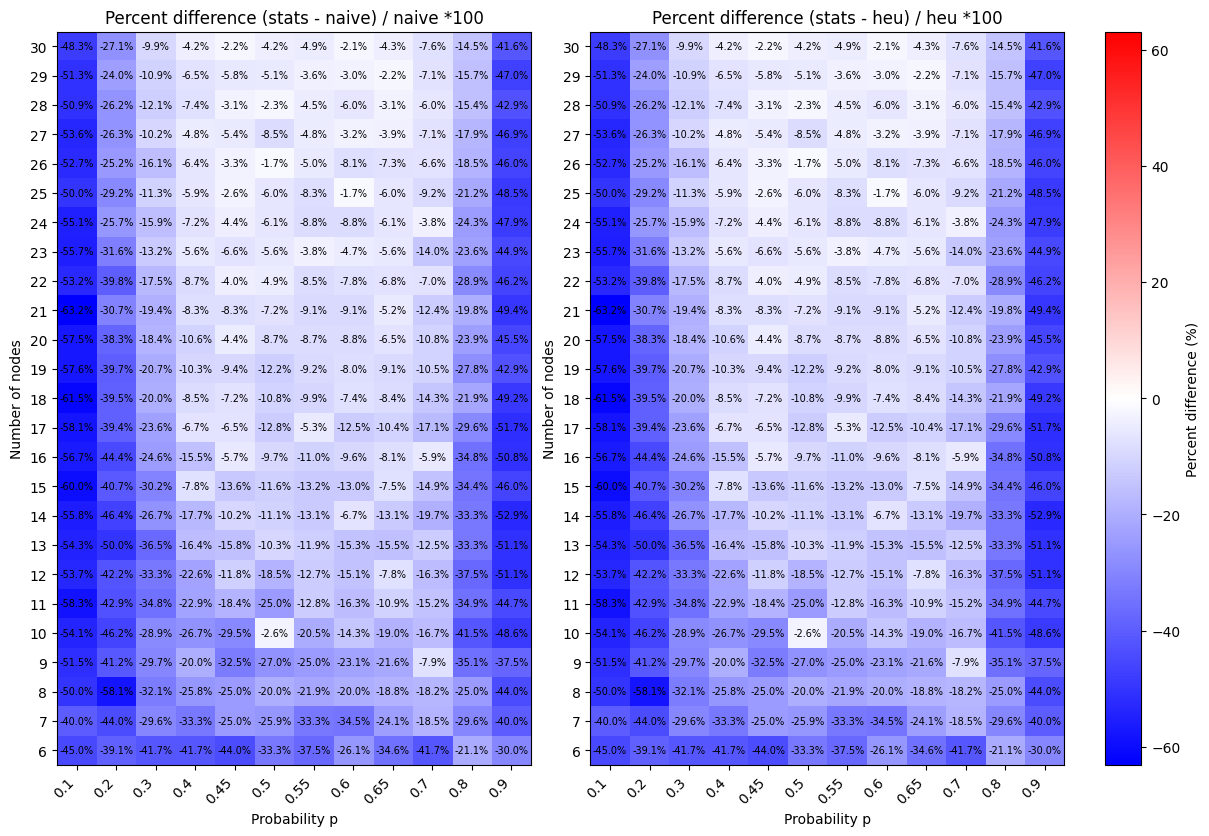

Saved /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/cnots_percentage_difference_stats_minus_states_naive_vs_heu.png


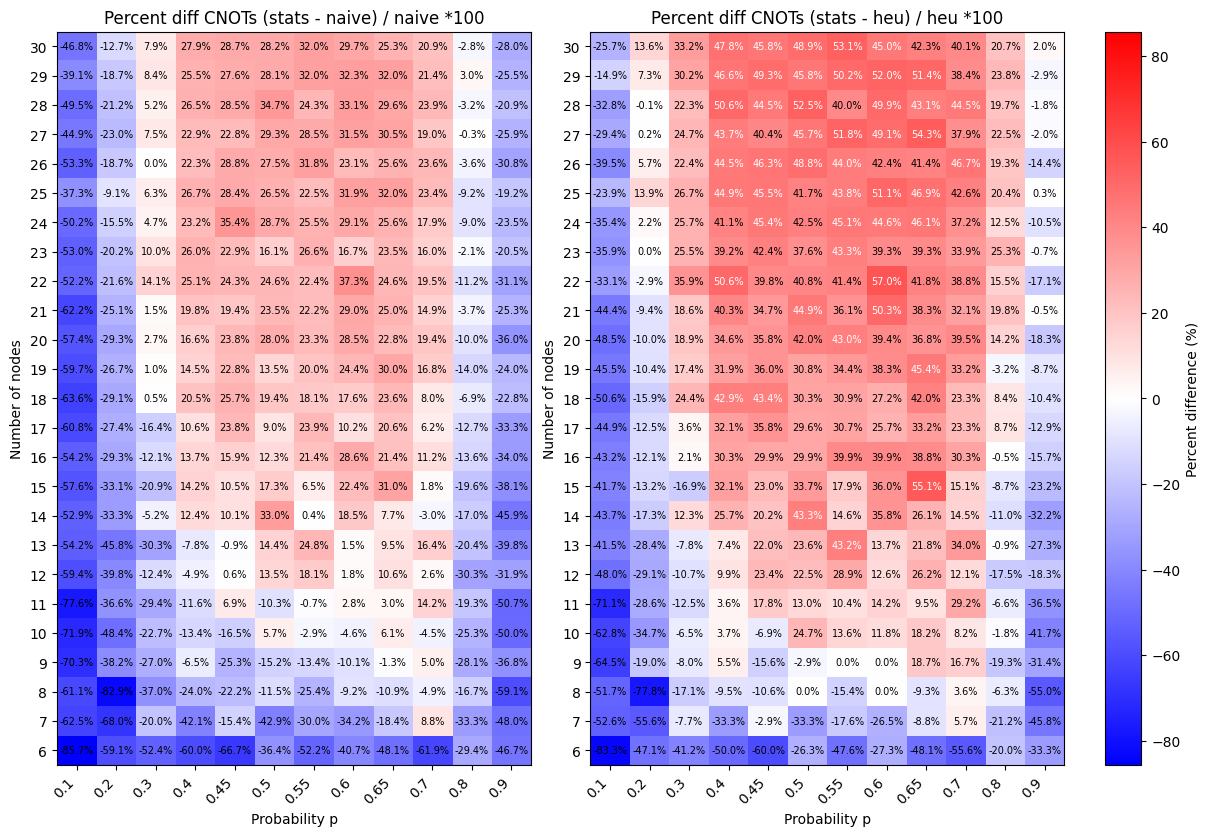

In [26]:
# Cell: Percentage difference plots for emitters and CNots (stats vs eva naive/heu)
# This cell computes percentage differences ((stats - eva)/eva * 100) and plots heatmaps
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_stats = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'graph_stats.csv')
csv_states = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'graph_stats_eva.csv')
if not os.path.exists(csv_stats):
    raise FileNotFoundError(f'Expected file not found: {csv_stats}')
if not os.path.exists(csv_states):
    raise FileNotFoundError(f'Expected file not found: {csv_states}')

# read files
df_stats = pd.read_csv(csv_stats)
df_states = pd.read_csv(csv_states)

# normalize numeric columns
df_stats['node_number'] = pd.to_numeric(df_stats['node_number'], errors='coerce')
df_stats['p'] = pd.to_numeric(df_stats['p'], errors='coerce')
df_states['node_number'] = pd.to_numeric(df_states['node_number'], errors='coerce')
df_states['p'] = pd.to_numeric(df_states['p'], errors='coerce')

# candidate column names for emitters
stats_col_candidates = ['num_emitters', 'num_emitter']
naive_col_candidates = ['num_emitter_naive','num_emitters_naive']
heu_col_candidates = ['num_emitters_heu','num_emitter_heu','num_heu']
stats_col = next((c for c in stats_col_candidates if c in df_stats.columns), None)
naive_col = next((c for c in naive_col_candidates if c in df_states.columns), None)
heu_col = next((c for c in heu_col_candidates if c in df_states.columns), None)
if stats_col is None:
    raise KeyError(f'Could not find any of {stats_col_candidates} in {csv_stats}')
if naive_col is None and heu_col is None:
    raise KeyError(f'Could not find any naive or heu emitter columns in {csv_states}')

# probability order
prob_list = [0.1,0.2,0.3,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.8,0.9]

# helper to build pivot
def build_pivot(df, col):
    if col is None:
        return None
    sub = df[df[col].notna() & df['node_number'].notna() & df['p'].notna()].copy()
    if sub.empty:
        return None
    group = sub.groupby(['node_number','p'])[col].mean().reset_index()
    pivot = group.pivot(index='node_number', columns='p', values=col)
    pivot = pivot.reindex(columns=prob_list)
    pivot = pivot.sort_index()
    return pivot

pivot_stats = build_pivot(df_stats, stats_col)
pivot_naive = build_pivot(df_states, naive_col)
pivot_heu = build_pivot(df_states, heu_col)

# union rows and reindex for alignment
rows = set()
if pivot_stats is not None:
    rows.update(pivot_stats.index.tolist())
if pivot_naive is not None:
    rows.update(pivot_naive.index.tolist())
if pivot_heu is not None:
    rows.update(pivot_heu.index.tolist())
all_nodes = sorted(rows)
if pivot_stats is not None:
    pivot_stats = pivot_stats.reindex(index=all_nodes)
if pivot_naive is not None:
    pivot_naive = pivot_naive.reindex(index=all_nodes)
if pivot_heu is not None:
    pivot_heu = pivot_heu.reindex(index=all_nodes)

# compute percentage differences safely: (stats - other)/other * 100
pct_diffs = {}
for label, pvt in (('naive', pivot_naive), ('heu', pivot_heu)):
    if pvt is None or pivot_stats is None:
        continue
    denom = pvt.astype(float).copy()
    # avoid division by zero: replace zeros with nan
    denom = denom.replace(0, np.nan)
    pct = (pivot_stats.astype(float) - pvt.astype(float)) / denom * 100.0
    pct_diffs[label] = pct.values.astype(float)

if not pct_diffs:
    raise RuntimeError('No percentage differences to plot (missing columns or stats)')

# plotting helper
for metric_label, diffs in (('emitters', pct_diffs),):
    # determine vmin/vmax symmetric in percent
    all_vals = np.hstack([v[np.isfinite(v)] for v in diffs.values()]) if any(np.isfinite(v).any() for v in diffs.values()) else np.array([])
    if all_vals.size:
        lim = max(abs(np.nanmin(all_vals)), abs(np.nanmax(all_vals)))
        vmin, vmax = -lim, lim
    else:
        vmin, vmax = None, None

    n = len(diffs)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, max(4, len(all_nodes)*0.25 + 2)), constrained_layout=True)
    if n == 1:
        axes = [axes]
    cmap = plt.get_cmap('bwr')
    for ax, label in zip(axes, diffs.keys()):
        data = diffs[label]
        im = ax.imshow(data, aspect='auto', origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_xticks(np.arange(len(prob_list)))
        ax.set_xticklabels([str(p) for p in prob_list], rotation=45, ha='right')
        ax.set_yticks(np.arange(len(all_nodes)))
        ax.set_yticklabels(all_nodes)
        ax.set_xlabel('Probability p')
        ax.set_ylabel('Number of nodes')
        ax.set_title(f'Percent difference (stats - {label}) / {label} *100')
        # annotate with percent values
        for r in range(data.shape[0]):
            for c in range(data.shape[1]):
                val = data[r, c]
                if np.isnan(val):
                    txt = ''
                else:
                    txt = f'{val:.1f}%'
                color = 'white' if (vmin is not None and val > 0 and abs(val) > (lim/2 if lim>0 else 0)) else 'black'
                ax.text(c, r, txt, ha='center', va='center', color=color, fontsize=7)
    fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04).set_label('Percent difference (%)')
    out_fig = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', f'emitters_percentage_difference_stats_minus_states_naive_vs_heu.png')
    fig.savefig(out_fig, dpi=300)
    print('Saved', out_fig)
    plt.show()

# Now repeat for CNots percentage differences
stats_cnots_candidates = ['num_emitter_CNOTs', 'num_cnots', 'cnots']
cnots_naive_candidates = ['cnots_naive']
cnots_heu_candidates = ['cnots_heu']
cnots_stats_col = next((c for c in stats_cnots_candidates if c in df_stats.columns), None)
cnots_naive_col = next((c for c in cnots_naive_candidates if c in df_states.columns), None)
cnots_heu_col = next((c for c in cnots_heu_candidates if c in df_states.columns), None)

pivot_stats_c = build_pivot(df_stats, cnots_stats_col)
pivot_naive_c = build_pivot(df_states, cnots_naive_col)
pivot_heu_c = build_pivot(df_states, cnots_heu_col)

rows_c = set()
if pivot_stats_c is not None:
    rows_c.update(pivot_stats_c.index.tolist())
if pivot_naive_c is not None:
    rows_c.update(pivot_naive_c.index.tolist())
if pivot_heu_c is not None:
    rows_c.update(pivot_heu_c.index.tolist())
all_nodes_c = sorted(rows_c)
if pivot_stats_c is not None:
    pivot_stats_c = pivot_stats_c.reindex(index=all_nodes_c)
if pivot_naive_c is not None:
    pivot_naive_c = pivot_naive_c.reindex(index=all_nodes_c)
if pivot_heu_c is not None:
    pivot_heu_c = pivot_heu_c.reindex(index=all_nodes_c)

pct_diffs_c = {}
for label, pvt in (('naive', pivot_naive_c), ('heu', pivot_heu_c)):
    if pvt is None or pivot_stats_c is None:
        continue
    denom = pvt.astype(float).copy()
    denom = denom.replace(0, np.nan)
    pct = (pivot_stats_c.astype(float) - pvt.astype(float)) / denom * 100.0
    pct_diffs_c[label] = pct.values.astype(float)

if pct_diffs_c:
    all_vals_c = np.hstack([v[np.isfinite(v)] for v in pct_diffs_c.values()]) if any(np.isfinite(v).any() for v in pct_diffs_c.values()) else np.array([])
    if all_vals_c.size:
        lim_c = max(abs(np.nanmin(all_vals_c)), abs(np.nanmax(all_vals_c)))
        vmin_c, vmax_c = -lim_c, lim_c
    else:
        vmin_c, vmax_c = None, None

    n_c = len(pct_diffs_c)
    fig_c2, axes_c2 = plt.subplots(1, n_c, figsize=(6 * n_c, max(4, len(all_nodes_c)*0.25 + 2)), constrained_layout=True)
    if n_c == 1:
        axes_c2 = [axes_c2]
    cmap_c = plt.get_cmap('bwr')
    for axc, label in zip(axes_c2, pct_diffs_c.keys()):
        data_c = pct_diffs_c[label]
        imc = axc.imshow(data_c, aspect='auto', origin='lower', cmap=cmap_c, vmin=vmin_c, vmax=vmax_c)
        axc.set_xticks(np.arange(len(prob_list)))
        axc.set_xticklabels([str(p) for p in prob_list], rotation=45, ha='right')
        axc.set_yticks(np.arange(len(all_nodes_c)))
        axc.set_yticklabels(all_nodes_c)
        axc.set_xlabel('Probability p')
        axc.set_ylabel('Number of nodes')
        axc.set_title(f'Percent diff CNOTs (stats - {label}) / {label} *100')
        for r in range(data_c.shape[0]):
            for c in range(data_c.shape[1]):
                val = data_c[r, c]
                if np.isnan(val):
                    txt = ''
                else:
                    txt = f'{val:.1f}%'
                color = 'white' if (vmin_c is not None and val > 0 and abs(val) > (lim_c/2 if lim_c>0 else 0)) else 'black'
                axc.text(c, r, txt, ha='center', va='center', color=color, fontsize=7)
    fig_c2.colorbar(imc, ax=axes_c2, fraction=0.046, pad=0.04).set_label('Percent difference (%)')
    out_fig_c_all = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'cnots_percentage_difference_stats_minus_states_naive_vs_heu.png')
    fig_c2.savefig(out_fig_c_all, dpi=300)
    print('Saved', out_fig_c_all)
    plt.show()
else:
    print('No CNOTs percentage diffs available (missing columns).')

Saved heatmap to /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/num_emitters_path_heatmap.png


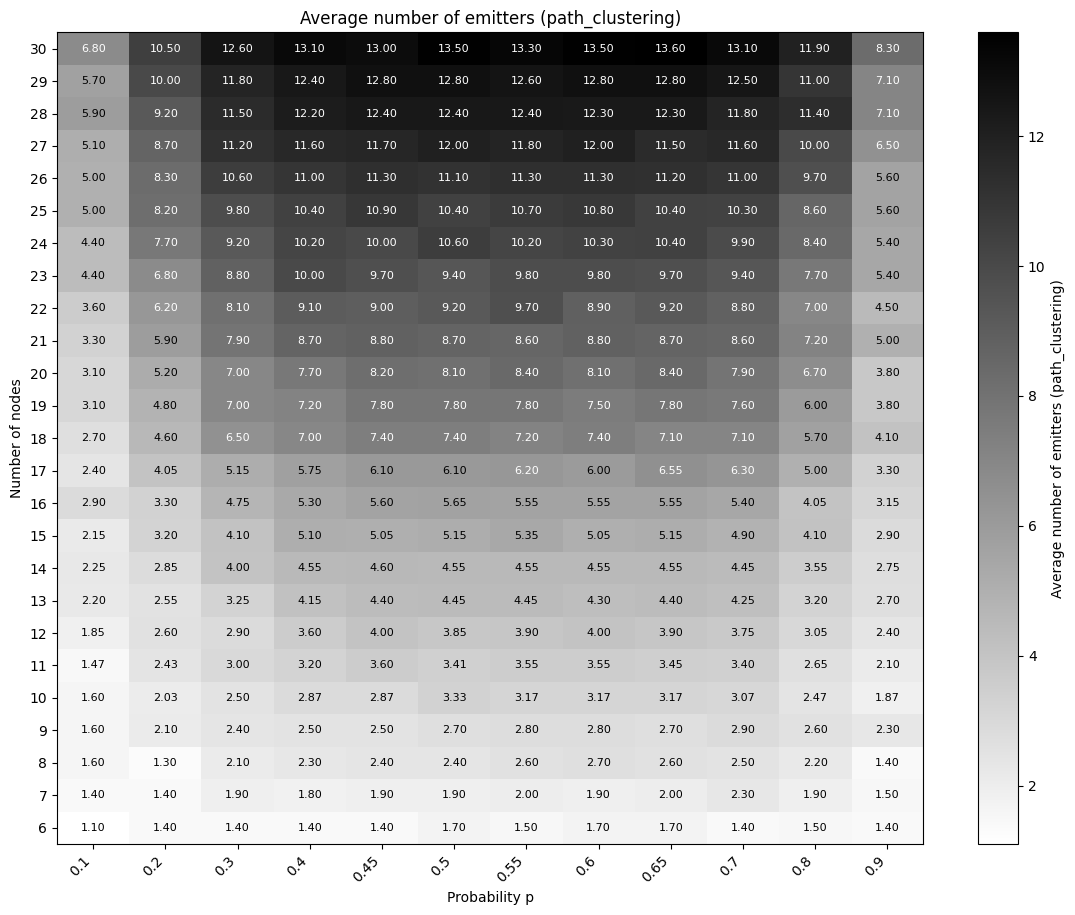

Saved heatmap to /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/num_emitter_CNOTs_path_heatmap.png


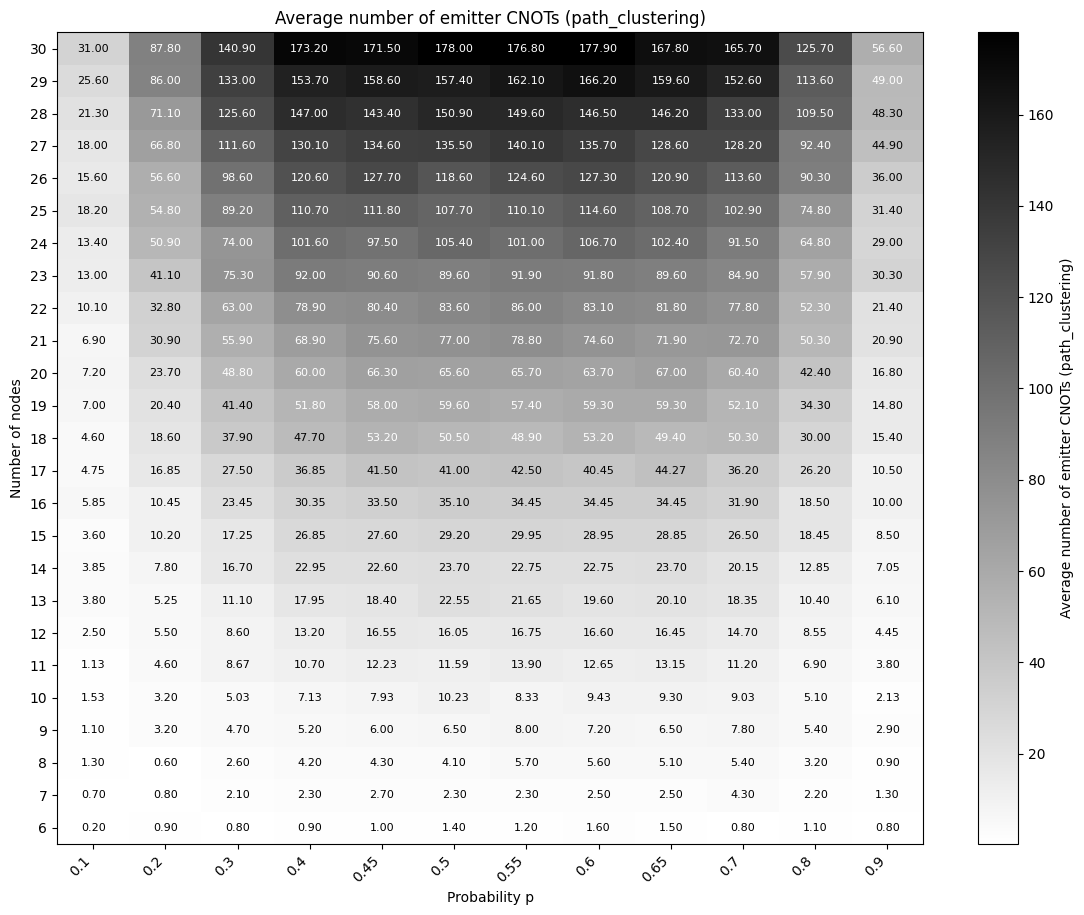

In [5]:
# Plot heatmaps for DP Ordering algorithm (emitters and CNOTs)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

csv_dp = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'graph_stats_path_clustering.csv')
if not os.path.exists(csv_dp):
    raise FileNotFoundError(f"Expected results CSV not found: {csv_dp}")

# Read results
df_dp = pd.read_csv(csv_dp)

# Normalize columns
df_dp['node_number'] = pd.to_numeric(df_dp['node_number'], errors='coerce')
df_dp['p'] = pd.to_numeric(df_dp['p'], errors='coerce')
df_dp = df_dp[df_dp['node_number'].notna() & df_dp['p'].notna()]

# Probability list
prob_list = [0.1,0.2,0.3,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.8,0.9]

# Metrics to plot
metrics = [
    ('num_emitters_path', 'Average number of emitters (path_clustering)'),
    ('num_emitter_CNOTs_path', 'Average number of emitter CNOTs (path_clustering)')
]

for col, title in metrics:
    if col not in df_dp.columns:
        print(f"Column {col} not found in {csv_dp} -- skipping.")
        continue
        
    # Group and pivot
    group = df_dp.groupby(['node_number','p'])[col].mean().reset_index()
    pivot = group.pivot(index='node_number', columns='p', values=col)
    pivot = pivot.reindex(columns=prob_list)
    pivot = pivot.sort_index()
    
    # Prepare data
    nodes = pivot.index.astype(int).tolist()
    probs = pivot.columns.tolist()
    data = pivot.values.astype(float)
    
    # Plot
    fig, ax = plt.subplots(figsize=(len(probs)*0.8 + 2, len(nodes)*0.25 + 3))
    cmap = plt.get_cmap('binary')
    im = ax.imshow(data, aspect='auto', origin='lower', cmap=cmap)
    
    # Ticks and labels
    ax.set_xticks(np.arange(len(probs)))
    ax.set_xticklabels([str(p) for p in probs], rotation=45, ha='right')
    ax.set_yticks(np.arange(len(nodes)))
    ax.set_yticklabels(nodes)
    ax.set_xlabel('Probability p')
    ax.set_ylabel('Number of nodes')
    ax.set_title(title)
    
    # Annotations
    mean_val = np.nanmean(data)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if np.isnan(val):
                txt = ''
            else:
                txt = f"{val:.2f}"
            color = 'white' if (not np.isnan(val) and val > mean_val) else 'black'
            ax.text(j, i, txt, ha='center', va='center', color=color, fontsize=8)
            
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(title)
    
    out_fig = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', f'{col}_heatmap.png')
    fig.tight_layout()
    fig.savefig(out_fig, dpi=300)
    print(f'Saved heatmap to {out_fig}')
    plt.show()

--- Processing Emitters ---
Saved /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/Emitters_diff_dp_vs_others.png


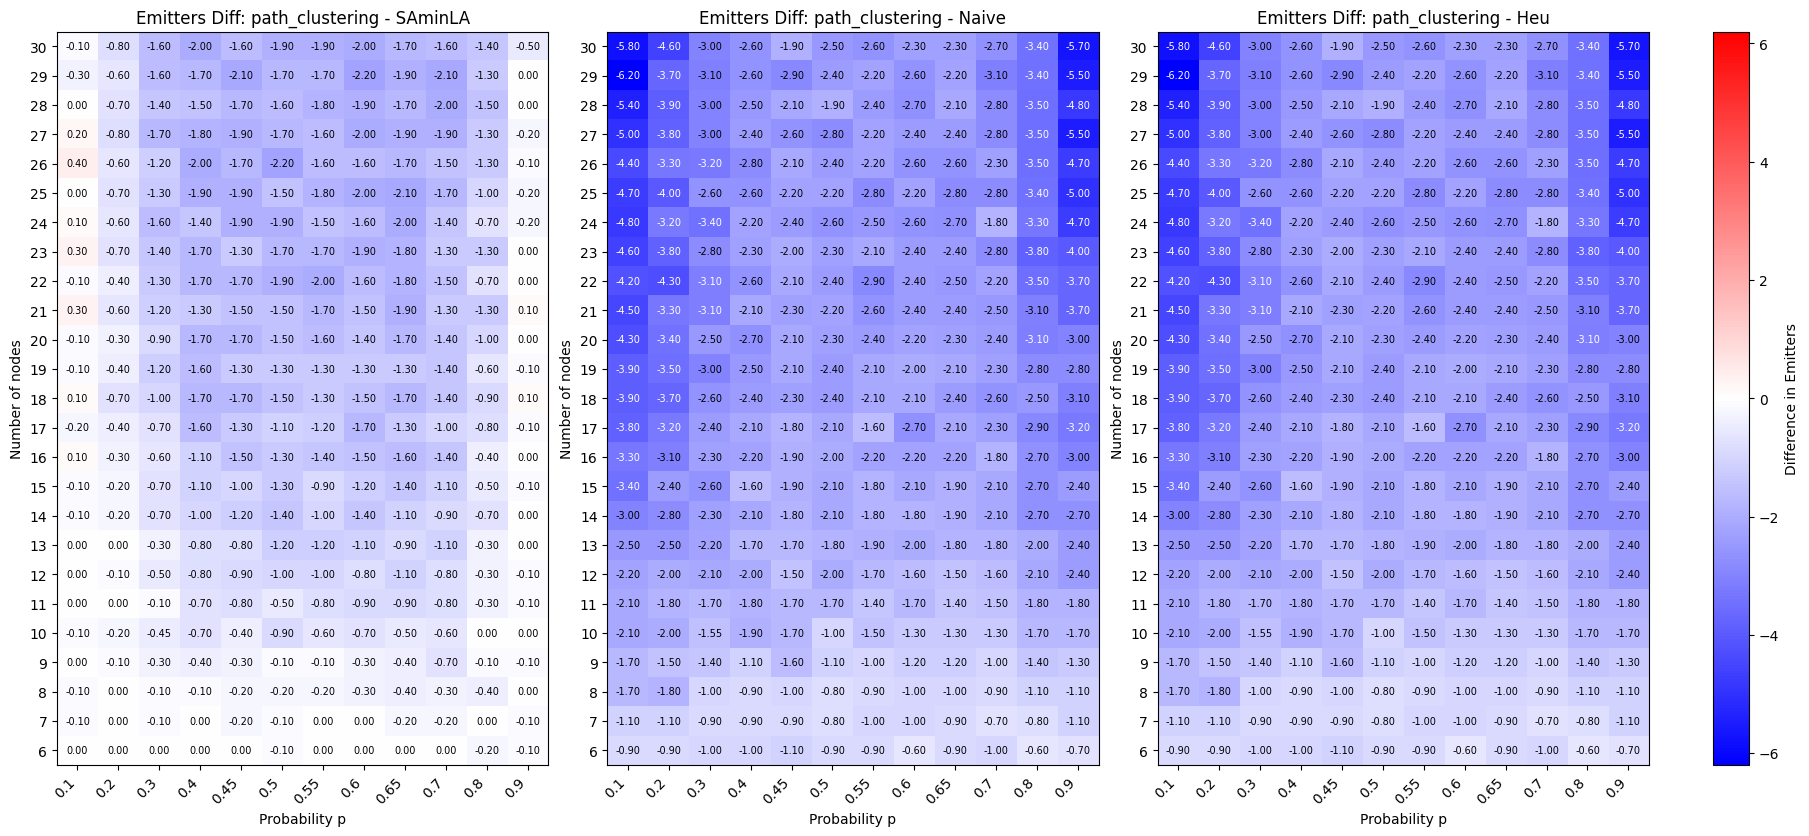

Saved /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/Emitters_pct_diff_dp_vs_others.png


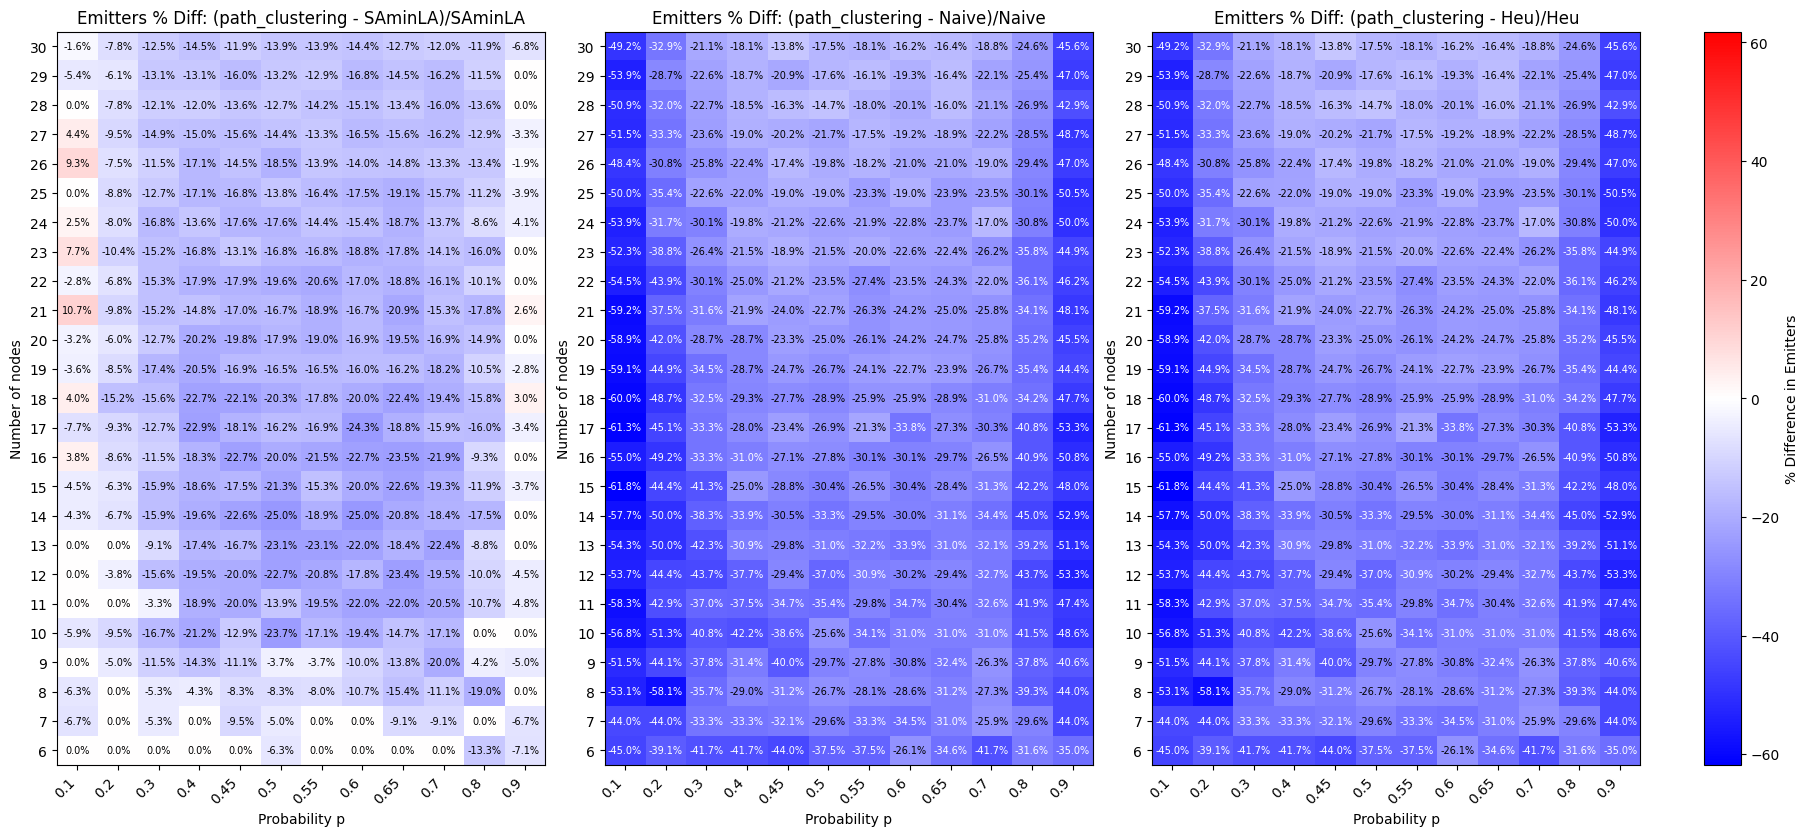

--- Processing CNOTs ---
Saved /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/CNOTs_diff_dp_vs_others.png


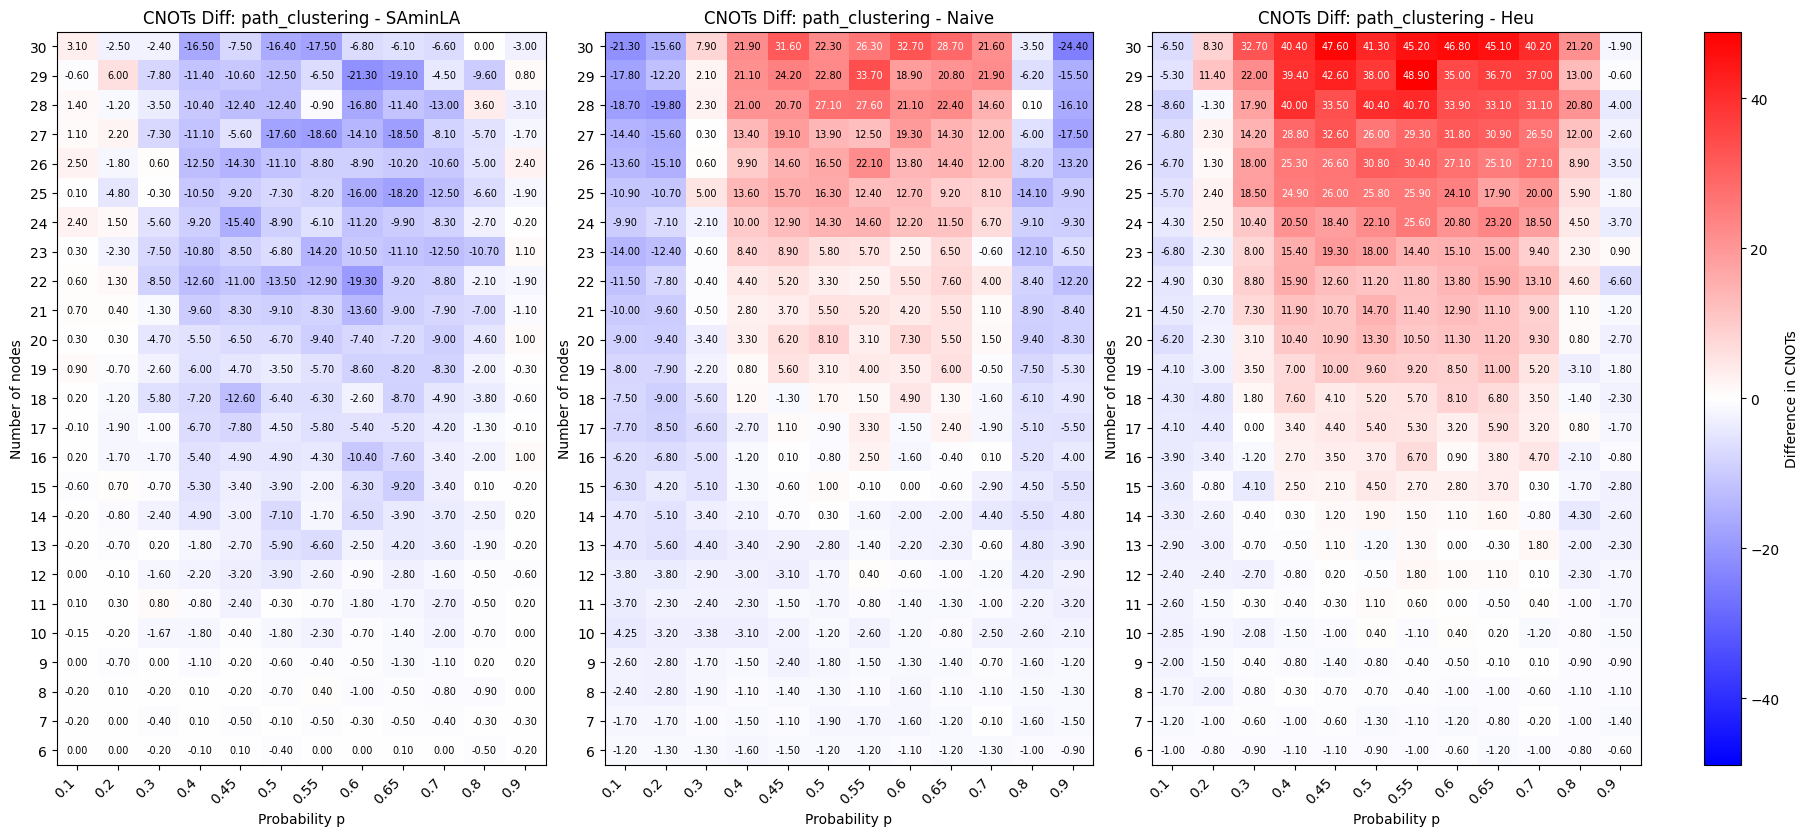

Saved /Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison/CNOTs_pct_diff_dp_vs_others.png


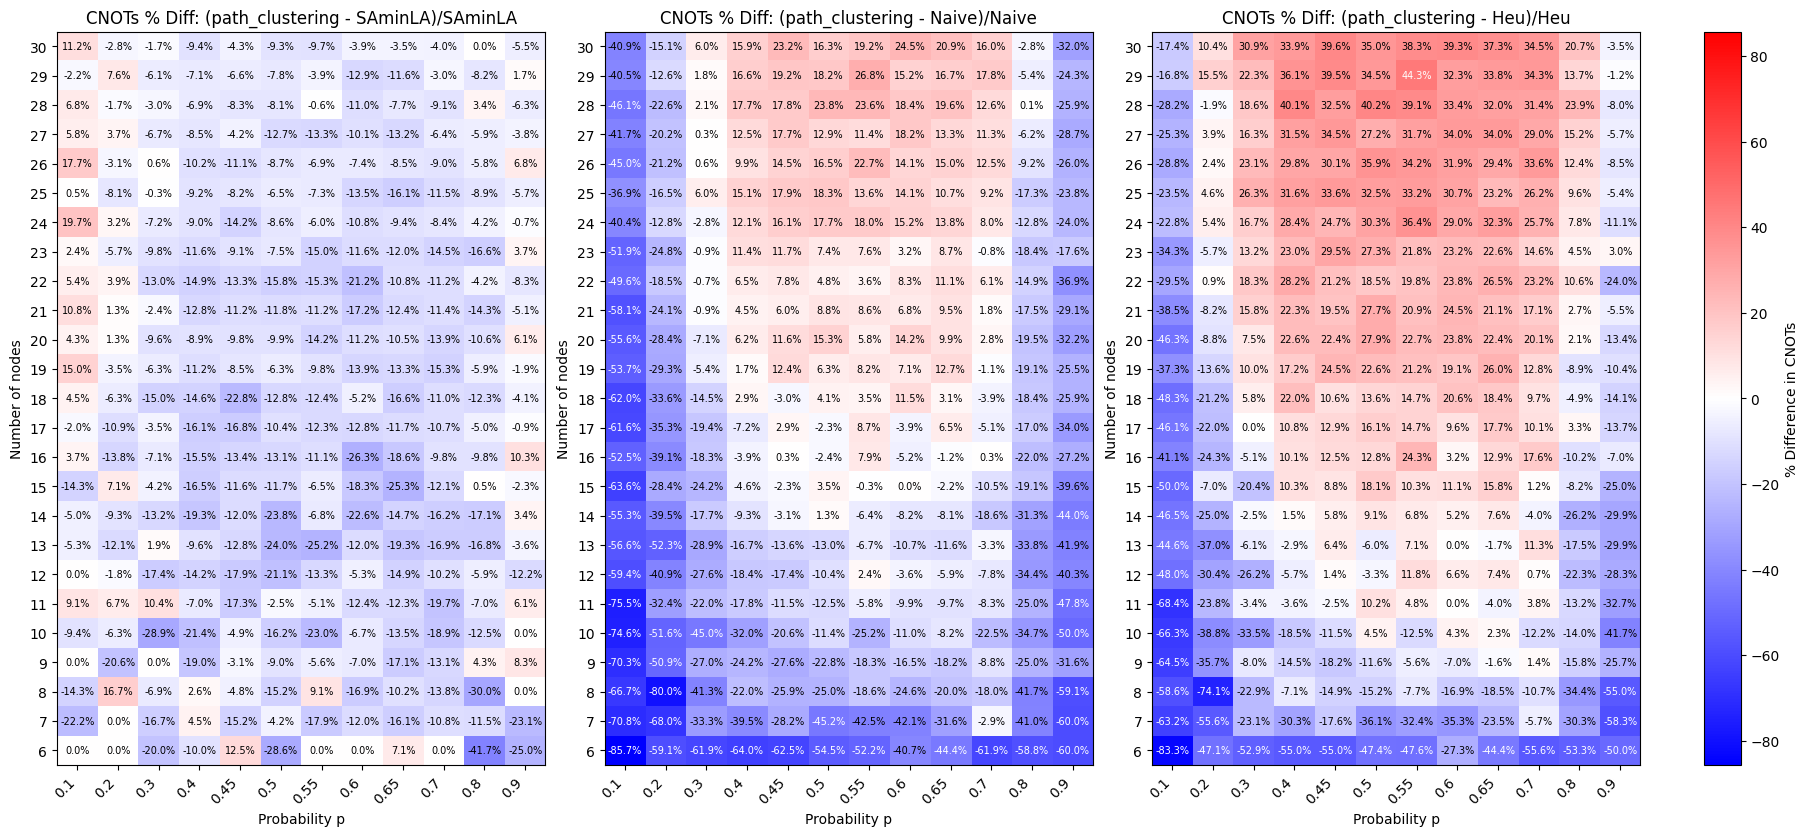

In [9]:
# Compare DP Ordering vs SAminLA, Naive, and Heu (Difference and % Difference)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# File paths
csv_stats = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'graph_stats.csv')       # SAminLA
csv_eva = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'graph_stats_eva.csv')     # Naive, Heu
csv_dp = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', 'graph_stats_path_clustering_default.csv') # DP Ordering

# Load Dataframes
df_stats = pd.read_csv(csv_stats)
df_eva = pd.read_csv(csv_eva)
df_dp = pd.read_csv(csv_dp)

# Normalize columns
for df in [df_stats, df_eva, df_dp]:
    df['node_number'] = pd.to_numeric(df['node_number'], errors='coerce')
    df['p'] = pd.to_numeric(df['p'], errors='coerce')

# Probability list
prob_list = [0.1,0.2,0.3,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.8,0.9]

# Helper to build pivot tables
def get_pivot(df, col_name):
    if col_name not in df.columns:
        return None
    sub = df[df[col_name].notna() & df['node_number'].notna() & df['p'].notna()]
    grp = sub.groupby(['node_number', 'p'])[col_name].mean().reset_index()
    pvt = grp.pivot(index='node_number', columns='p', values=col_name)
    pvt = pvt.reindex(columns=prob_list)
    pvt = pvt.sort_index()
    return pvt

# Define metrics and their columns in respective files
# Structure: (Metric Name, DP_Col, SA_Col, Naive_Col, Heu_Col)
metrics_config = [
    ('Emitters', 'num_emitters_path', 'num_emitters', 'num_emitters_naive', 'num_emitters_heu'),
    ('CNOTs', 'num_emitter_CNOTs_path', 'num_emitter_CNOTs', 'cnots_naive', 'cnots_heu')
]

for metric_name, dp_col, sa_col, naive_col, heu_col in metrics_config:
    print(f"--- Processing {metric_name} ---")
    
    # Get pivots
    pvt_dp = get_pivot(df_dp, dp_col)
    pvt_sa = get_pivot(df_stats, sa_col)
    pvt_naive = get_pivot(df_eva, naive_col)
    pvt_heu = get_pivot(df_eva, heu_col)
    
    if pvt_dp is None:
        print(f"DP column {dp_col} missing. Skipping {metric_name}.")
        continue

    # Align all pivots to the union of their indices
    all_indices = set(pvt_dp.index)
    if pvt_sa is not None: all_indices.update(pvt_sa.index)
    if pvt_naive is not None: all_indices.update(pvt_naive.index)
    if pvt_heu is not None: all_indices.update(pvt_heu.index)
    
    sorted_indices = sorted(list(all_indices))
    
    pvt_dp = pvt_dp.reindex(sorted_indices)
    targets = {
        'SAminLA': pvt_sa.reindex(sorted_indices) if pvt_sa is not None else None,
        'Naive': pvt_naive.reindex(sorted_indices) if pvt_naive is not None else None,
        'Heu': pvt_heu.reindex(sorted_indices) if pvt_heu is not None else None
    }
    
    # 1. Plot Absolute Differences (DP - Other)
    valid_targets = {k: v for k, v in targets.items() if v is not None}
    if not valid_targets:
        print(f"No comparison data found for {metric_name}.")
        continue
        
    n = len(valid_targets)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, max(4, len(sorted_indices)*0.25 + 2)), constrained_layout=True)
    if n == 1: axes = [axes]
    
    # Calculate global vmin/vmax for symmetric colorbar
    all_diffs = []
    diff_maps = {}
    for label, target_pvt in valid_targets.items():
        diff = pvt_dp.values - target_pvt.values
        diff_maps[label] = diff
        all_diffs.append(diff[np.isfinite(diff)])
    
    if all_diffs:
        concat_diffs = np.hstack(all_diffs)
        lim = max(abs(np.nanmin(concat_diffs)), abs(np.nanmax(concat_diffs))) if concat_diffs.size > 0 else 1
        vmin, vmax = -lim, lim
    else:
        vmin, vmax = -1, 1

    cmap = plt.get_cmap('bwr')
    
    for ax, (label, diff) in zip(axes, diff_maps.items()):
        im = ax.imshow(diff, aspect='auto', origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
        
        ax.set_xticks(np.arange(len(prob_list)))
        ax.set_xticklabels([str(p) for p in prob_list], rotation=45, ha='right')
        ax.set_yticks(np.arange(len(sorted_indices)))
        ax.set_yticklabels(sorted_indices)
        ax.set_xlabel('Probability p')
        ax.set_ylabel('Number of nodes')
        ax.set_title(f'{metric_name} Diff: path_clustering - {label}')
        
        # Annotate
        for r in range(diff.shape[0]):
            for c in range(diff.shape[1]):
                val = diff[r, c]
                if np.isnan(val): continue
                txt = f'{val:.2f}'
                color = 'white' if abs(val) > lim/2 else 'black'
                ax.text(c, r, txt, ha='center', va='center', color=color, fontsize=7)
                
    fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04).set_label(f'Difference in {metric_name}')
    out_fig = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', f'{metric_name}_diff_dp_vs_others.png')
    fig.savefig(out_fig, dpi=300)
    print(f'Saved {out_fig}')
    plt.show()
    
    # 2. Plot Percentage Differences (DP - Other) / Other * 100
    fig, axes = plt.subplots(1, n, figsize=(6 * n, max(4, len(sorted_indices)*0.25 + 2)), constrained_layout=True)
    if n == 1: axes = [axes]
    
    all_pcts = []
    pct_maps = {}
    for label, target_pvt in valid_targets.items():
        denom = target_pvt.values.copy()
        denom[denom == 0] = np.nan # Avoid div by zero
        pct = (pvt_dp.values - target_pvt.values) / denom * 100.0
        pct_maps[label] = pct
        all_pcts.append(pct[np.isfinite(pct)])
        
    if all_pcts:
        concat_pcts = np.hstack(all_pcts)
        lim = max(abs(np.nanmin(concat_pcts)), abs(np.nanmax(concat_pcts))) if concat_pcts.size > 0 else 1
        vmin, vmax = -lim, lim
    else:
        vmin, vmax = -1, 1
        
    for ax, (label, pct) in zip(axes, pct_maps.items()):
        im = ax.imshow(pct, aspect='auto', origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
        
        ax.set_xticks(np.arange(len(prob_list)))
        ax.set_xticklabels([str(p) for p in prob_list], rotation=45, ha='right')
        ax.set_yticks(np.arange(len(sorted_indices)))
        ax.set_yticklabels(sorted_indices)
        ax.set_xlabel('Probability p')
        ax.set_ylabel('Number of nodes')
        ax.set_title(f'{metric_name} % Diff: (path_clustering - {label})/{label}')
        
        # Annotate
        for r in range(pct.shape[0]):
            for c in range(pct.shape[1]):
                val = pct[r, c]
                if np.isnan(val): continue
                txt = f'{val:.1f}%'
                color = 'white' if abs(val) > lim/2 else 'black'
                ax.text(c, r, txt, ha='center', va='center', color=color, fontsize=7)
                
    fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04).set_label(f'% Difference in {metric_name}')
    out_fig = os.path.join('/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/algos_comparison', f'{metric_name}_pct_diff_dp_vs_others.png')
    fig.savefig(out_fig, dpi=300)
    print(f'Saved {out_fig}')
    plt.show()